# **Hypothesis Tests**

## Project
**Using Machine Learning to Predict Complaint Resolution Outcomes in Retail Banking: Evidence from Open Consumer Financial Complaint Data**

## Purpose of this notebook
This notebook performs the formal hypothesis testing for the capstone project and enriches the analysis with business-friendly diagnostics.

It covers:

1. **RQ1:** Product type and timely response  
2. **RQ2:** Issue category and company response outcome  
3. **RQ3:** Narrative features and predictive performance  
4. **RQ4:** Company/geographic differences and complaint-resolution outcomes  

## Enhancements added
This enhanced version includes:

- clearer test parameters and assumptions;
- chi-square assumption diagnostics;
- Cramer's V effect-size interpretation;
- standardized residuals for post-hoc category review;
- row-percentage contingency tables;
- issue/response dependency checks;
- categorical dependency matrix using Cramer's V;
- richer bivariate rate tables;
- optional TF-IDF narrative model comparison;
- business interpretation tables for final reporting.


## Statistical Methods Used

This notebook uses a combination of statistical tests and predictive model comparisons.

1. **Chi-square test of independence**  
   Used to test whether two categorical variables are statistically associated.

2. **Cramer's V**  
   Used as the effect-size measure for chi-square tests. This is important because a large dataset can produce a very small p-value even when the business effect is small.

3. **Standardized residuals**  
   Used to identify which categories contribute most to a significant chi-square result.

4. **Binary logistic regression**  
   Used to estimate the probability of timely response and compare structured-only versus narrative-enhanced models.

5. **Model evaluation metrics**  
   Accuracy, balanced accuracy, precision, recall, F1-score, ROC-AUC, and PR-AUC are used to compare predictive performance.

6. **Business interpretation**  
   Results are framed as association and risk signals, not causal proof.


In [42]:
# -------------------------------------------------------------------
# Mount Google Drive
# -------------------------------------------------------------------
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [43]:
# -------------------------------------------------------------------
# Import libraries
# -------------------------------------------------------------------
from pathlib import Path
from datetime import datetime
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import chi2_contingency
from statsmodels.stats.proportion import proportions_ztest

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 150)
pd.set_option("display.max_rows", 150)
pd.set_option("display.width", 180)

print("Libraries loaded successfully.")


Libraries loaded successfully.


In [44]:
# -------------------------------------------------------------------
# Project folders and file paths
# -------------------------------------------------------------------
PROJECT_ROOT = Path("/content/drive/MyDrive/retail-complaint-resolution-ml")

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
OUTPUT_TABLES = PROJECT_ROOT / "outputs" / "tables"
OUTPUT_FIGURES = PROJECT_ROOT / "outputs" / "figures"

for folder in [DATA_PROCESSED, OUTPUT_TABLES, OUTPUT_FIGURES]:
    folder.mkdir(parents=True, exist_ok=True)

PROCESSED_FILE = DATA_PROCESSED / "cfpb_retail_complaints_2017_2025.csv"

print("Project root:", PROJECT_ROOT)
print("Processed input file:", PROCESSED_FILE)
print("File exists:", PROCESSED_FILE.exists())

Project root: /content/drive/MyDrive/retail-complaint-resolution-ml
Processed input file: /content/drive/MyDrive/retail-complaint-resolution-ml/data/processed/cfpb_retail_complaints_2017_2025.csv
File exists: True


In [45]:
# -------------------------------------------------------------------
# Check processed dataset exists
# -------------------------------------------------------------------
if not PROCESSED_FILE.exists():
    raise FileNotFoundError(
        "Processed dataset not found. Please run 01_data_extraction.ipynb first. "
        f"Expected file: {PROCESSED_FILE}"
    )

print("Processed dataset found.")
print(f"File size: {PROCESSED_FILE.stat().st_size / (1024**2):,.2f} MB")
print(f"Last modified: {datetime.fromtimestamp(PROCESSED_FILE.stat().st_mtime)}")

Processed dataset found.
File size: 1,241.13 MB
Last modified: 2026-07-15 21:18:36


## Step 1: Load Processed Dataset

The processed file is loaded from Google Drive. The notebook then confirms that the main target fields exist.

In [46]:
# -------------------------------------------------------------------
# Load processed dataset
# -------------------------------------------------------------------
df = pd.read_csv(PROCESSED_FILE, low_memory=False)

print("Dataset loaded.")
print("Rows:", f"{df.shape[0]:,}")
print("Columns:", f"{df.shape[1]:,}")

df.head()

Dataset loaded.
Rows: 1,289,027
Columns: 25


,date_received,product,sub_product,issue,sub_issue,consumer_complaint_narrative,company_public_response,company,state,zip_code,tags,submitted_via,date_sent_to_company,company_response_to_consumer,timely_response,complaint_id,date_received_raw,date_sent_to_company_raw,year_received,month_received,quarter_received,timely_response_binary,has_narrative,narrative_length,received_to_sent_lag_days
0,2025-07-05 08:45:32+00:00,Mortgage,Conventional home mortgage,Applying for a mortgage or refinancing an exis...,Changes in loan terms during the application p...,I signed an initial disclosure for a XXXX mort...,Company believes the complaint is the result o...,"Your Favorite Lenders, Inc",OH,441XX,NaN,Web,2026-05-05 13:43:00+00:00,Closed with explanation,Yes,21636268,2025-07-05T08:45:32.000Z,2026-05-05T13:43:00.000Z,2025,2025-07,2025Q3,1,1,516,304.0
1,2025-07-11 03:39:40+00:00,"Payday loan, title loan, personal loan, or adv...",Payday loan,Charged fees or interest you didn't expect,NaN,I am filing a complaint against Integra Credit...,NaN,"Deinde Online Services, LLC",FL,33068,NaN,Web,2026-04-21 17:42:21+00:00,Closed with explanation,Yes,21447929,2025-07-11T03:39:40.000Z,2026-04-21T17:42:21.000Z,2025,2025-07,2025Q3,1,1,998,284.0
2,2025-08-11 18:59:48+00:00,Mortgage,Conventional home mortgage,Struggling to pay mortgage,Trying to communicate with the company to fix ...,NaN,NaN,"Del Toro Loan Servicing, Inc",CA,94552,Older American,Phone,2025-08-15 06:00:26+00:00,Closed with explanation,No,15198684,2025-08-11T18:59:48.000Z,2025-08-15T06:00:26.000Z,2025,2025-08,2025Q3,0,0,0,3.0
3,2025-08-17 01:15:29+00:00,Mortgage,Conventional home mortgage,Applying for a mortgage or refinancing an exis...,Loan estimate or other related disclosures,"Dear all, My name is XXXX XXXX, my address is ...",Company disputes the facts presented in the co...,"RESCO, INC.",HI,96815,NaN,Web,2026-05-04 13:13:09+00:00,Closed with explanation,Yes,21848458,2025-08-17T01:15:29.000Z,2026-05-04T13:13:09.000Z,2025,2025-08,2025Q3,1,1,1805,260.0
4,2025-09-25 15:49:13+00:00,Mortgage,VA mortgage,Applying for a mortgage or refinancing an exis...,Loan estimate or other related disclosures,NaN,NaN,"Mortgage Express, Inc.",GA,30662,Servicemember,Web,2026-04-30 15:44:57+00:00,Closed with explanation,Yes,21669790,2025-09-25T15:49:13.000Z,2026-04-30T15:44:57.000Z,2025,2025-09,2025Q3,1,0,0,216.0


In [47]:
# -------------------------------------------------------------------
# Basic field preparation
# -------------------------------------------------------------------
# Convert dates if present
for col in ["date_received", "date_sent_to_company"]:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce", utc=True)

# Create year if missing
if "year_received" not in df.columns and "date_received" in df.columns:
    df["year_received"] = df["date_received"].dt.year

# Create binary target if missing
if "timely_response_binary" not in df.columns:
    df["timely_response_binary"] = (
        df["timely_response"]
        .astype(str)
        .str.lower()
        .str.strip()
        .map({"yes": 1, "no": 0})
    )

# Create narrative features if missing
if "has_narrative" not in df.columns:
    df["has_narrative"] = df["consumer_complaint_narrative"].notna().astype(int)

if "narrative_length" not in df.columns:
    df["narrative_length"] = df["consumer_complaint_narrative"].fillna("").astype(str).str.len()

print("Preparation complete.")
print("Valid timely_response_binary records:", df["timely_response_binary"].notna().sum())

Preparation complete.
Valid timely_response_binary records: 1289027


## Step 2: Helper Functions

The following helper functions are used throughout the hypothesis testing notebook.

In [48]:

# -------------------------------------------------------------------
# Helper functions
# -------------------------------------------------------------------

ALPHA = 0.05
RANDOM_STATE = 42


def save_table(table, filename, index=False):
    "Save a table to the output tables folder."
    output_path = OUTPUT_TABLES / filename
    table.to_csv(output_path, index=index)
    print(f"Saved table: {output_path}")
    return output_path


def save_current_figure(filename, dpi=150):
    "Save the current matplotlib figure."
    output_path = OUTPUT_FIGURES / filename
    plt.savefig(output_path, dpi=dpi, bbox_inches="tight")
    print(f"Saved figure: {output_path}")
    return output_path


def group_top_categories(series, top_n=25, other_label="Other"):
    "Keep top N categories and group the rest as Other."
    top_values = series.value_counts(dropna=True).head(top_n).index
    return np.where(series.isin(top_values), series, other_label)


def cramers_v_from_table(contingency_table, correction=False):
    "Calculate Cramer's V effect size for a contingency table."
    if contingency_table.empty:
        return np.nan

    chi2, p, dof, expected = chi2_contingency(contingency_table, correction=correction)
    n = contingency_table.values.sum()
    r, k = contingency_table.shape

    if n == 0 or min(r - 1, k - 1) == 0:
        return np.nan

    return np.sqrt((chi2 / n) / min(k - 1, r - 1))


def interpret_p_value(p_value, alpha=ALPHA):
    if pd.isna(p_value):
        return "Not applicable."
    if p_value < alpha:
        return "Reject H0: statistically significant association."
    return "Fail to reject H0: no statistically significant association."


def interpret_cramers_v(v):
    "General interpretation guide for Cramer's V."
    if pd.isna(v):
        return "Effect size unavailable."
    if v < 0.10:
        return "Very weak effect size."
    elif v < 0.30:
        return "Weak effect size."
    elif v < 0.50:
        return "Moderate effect size."
    else:
        return "Strong effect size."


def expected_count_diagnostics(expected):
    "Return chi-square expected-count diagnostics."
    expected_array = np.asarray(expected)
    total_cells = expected_array.size
    cells_lt_5 = int((expected_array < 5).sum())
    pct_lt_5 = round(cells_lt_5 / total_cells * 100, 2) if total_cells > 0 else np.nan

    return {
        "min_expected_count": round(float(np.nanmin(expected_array)), 4),
        "cells_expected_less_than_5": cells_lt_5,
        "pct_cells_expected_less_than_5": pct_lt_5,
        "expected_count_assumption": "Review/caution" if pct_lt_5 > 20 else "Acceptable"
    }


def standardized_residuals(observed, expected):
    "Calculate standardized residuals for post-hoc review."
    expected_df = pd.DataFrame(expected, index=observed.index, columns=observed.columns)
    residuals = (observed - expected_df) / np.sqrt(expected_df)
    return residuals


def run_chi_square_test(dataframe, row_var, col_var, filename_prefix, correction=False):
    "Run chi-square test, save diagnostics, and return all important outputs."
    test_df = dataframe[[row_var, col_var]].dropna().copy()

    observed = pd.crosstab(test_df[row_var], test_df[col_var])
    chi2, p_value, dof, expected = chi2_contingency(observed, correction=correction)

    effect_size = cramers_v_from_table(observed, correction=correction)
    diagnostics = expected_count_diagnostics(expected)

    summary = pd.DataFrame([{
        "row_variable": row_var,
        "column_variable": col_var,
        "n_records": int(observed.values.sum()),
        "chi_square": chi2,
        "degrees_of_freedom": dof,
        "p_value": p_value,
        "alpha": ALPHA,
        "cramers_v": effect_size,
        "correction_used": correction,
        **diagnostics
    }])

    expected_df = pd.DataFrame(
        expected,
        index=observed.index,
        columns=observed.columns
    )

    row_pct = observed.div(observed.sum(axis=1), axis=0).mul(100).round(2)
    residuals = standardized_residuals(observed, expected).round(3)

    residuals_long = (
        residuals
        .reset_index()
        .melt(id_vars=row_var, var_name=col_var, value_name="standardized_residual")
        .sort_values("standardized_residual", key=lambda s: s.abs(), ascending=False)
    )

    save_table(observed.reset_index(), f"{filename_prefix}_observed_counts.csv")
    save_table(expected_df.reset_index(), f"{filename_prefix}_expected_counts.csv")
    save_table(row_pct.reset_index(), f"{filename_prefix}_row_percent.csv")
    save_table(residuals.reset_index(), f"{filename_prefix}_standardized_residuals.csv")
    save_table(residuals_long, f"{filename_prefix}_top_residuals_long.csv")
    save_table(summary, f"{filename_prefix}_test_summary.csv")

    return summary, observed.reset_index(), expected_df.reset_index(), row_pct.reset_index(), residuals.reset_index(), residuals_long


def plot_metric_comparison(metric_table, title, filename):
    "Plot available classification metrics for model comparison."
    plot_df = metric_table.copy()
    plot_df = plot_df[~plot_df["model"].str.contains("Difference", case=False, na=False)]
    plot_df = plot_df.set_index("model")

    candidate_metrics = [
        "accuracy",
        "balanced_accuracy",
        "precision",
        "recall",
        "f1",
        "roc_auc",
        "average_precision"
    ]
    available_metrics = [m for m in candidate_metrics if m in plot_df.columns]

    plt.figure(figsize=(11, 5))
    plot_df[available_metrics].plot(kind="bar", figsize=(11, 5))
    plt.title(title)
    plt.ylabel("Score")
    plt.xticks(rotation=25, ha="right")
    plt.ylim(0, 1)
    plt.tight_layout()

    output_path = OUTPUT_FIGURES / filename
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()

    print("Saved figure:", output_path)
    return output_path


def evaluate_binary_model(model, X_test, y_test, model_name):
    "Evaluate a binary classifier with imbalance-aware metrics."
    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_score)
        avg_precision = average_precision_score(y_test, y_score)
    else:
        roc_auc = np.nan
        avg_precision = np.nan

    metrics = {
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc,
        "average_precision": avg_precision
    }

    return metrics, y_pred


def safe_one_hot_encoder(min_frequency=50):
    "Create a OneHotEncoder that works across different scikit-learn versions."
    try:
        return OneHotEncoder(handle_unknown="ignore", min_frequency=min_frequency)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore")


print("Enhanced helper functions loaded.")


Enhanced helper functions loaded.


## Step 3: Analysis Dataset

Rows with missing target values are removed. This creates the analysis-ready dataset used in the tests below.

In [49]:
# -------------------------------------------------------------------
# Build analysis dataset
# -------------------------------------------------------------------
analysis_df = df.dropna(subset=["timely_response_binary"]).copy()

print("Original rows:", f"{len(df):,}")
print("Rows with valid timely_response_binary:", f"{len(analysis_df):,}")

target_counts = analysis_df["timely_response_binary"].value_counts(dropna=False).reset_index()
target_counts.columns = ["timely_response_binary", "count"]
target_counts["percent"] = (target_counts["count"] / target_counts["count"].sum() * 100).round(2)

save_table(target_counts, "hypothesis_target_timely_response_binary_counts.csv")

target_counts

Original rows: 1,289,027
Rows with valid timely_response_binary: 1,289,027
Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/hypothesis_target_timely_response_binary_counts.csv


,timely_response_binary,count,percent
0,1,1270902,98.59
1,0,18125,1.41


## Step 3A: Hypothesis Testing Parameters and Assumptions

The following parameters will be used consistently across the hypothesis tests:

- **Significance level:** α = 0.05  
- **Decision rule:** reject H0 when p-value < 0.05  
- **Effect size:** Cramer's V for chi-square tests  
- **Assumption check:** expected cell counts should generally be 5 or higher  
- **Business caution:** statistical significance does not automatically mean business importance, especially with a large dataset.


In [50]:
# -------------------------------------------------------------------
# Hypothesis testing parameter summary
# -------------------------------------------------------------------

test_parameters = pd.DataFrame([
    {
        "parameter": "alpha",
        "value": ALPHA,
        "purpose": "Threshold for statistical significance."
    },
    {
        "parameter": "chi_square_correction",
        "value": "False",
        "purpose": "Yates correction is not used because most tests are not simple 2 x 2 tables."
    },
    {
        "parameter": "effect_size",
        "value": "Cramer's V",
        "purpose": "Assesses practical strength of categorical association."
    },
    {
        "parameter": "expected_count_rule",
        "value": "Expected counts generally >= 5",
        "purpose": "Checks reliability of chi-square approximation."
    },
    {
        "parameter": "model_comparison_metric",
        "value": "ROC-AUC, PR-AUC, F1, precision, recall",
        "purpose": "Evaluates predictive usefulness beyond statistical testing."
    }
])

save_table(test_parameters, "hypothesis_testing_parameters.csv")
test_parameters


Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/hypothesis_testing_parameters.csv


,parameter,value,purpose
0,alpha,0.05,Threshold for statistical significance.
1,chi_square_correction,False,Yates correction is not used because most test...
2,effect_size,Cramer's V,Assesses practical strength of categorical ass...
3,expected_count_rule,Expected counts generally >= 5,Checks reliability of chi-square approximation.
4,model_comparison_metric,"ROC-AUC, PR-AUC, F1, precision, recall",Evaluates predictive usefulness beyond statist...


## Step 3B: Analysis Dataset Quality Check

Before formal hypothesis testing, this section checks target balance, missing values, and key categorical coverage. This helps confirm whether the hypothesis tests are based on sufficient and usable data.


In [51]:
# -------------------------------------------------------------------
# Analysis dataset quality and missingness check
# -------------------------------------------------------------------

key_fields = [
    "product",
    "issue",
    "sub_issue",
    "company",
    "state",
    "submitted_via",
    "company_response_to_consumer",
    "timely_response",
    "timely_response_binary",
    "has_narrative",
    "narrative_length"
]

available_key_fields = [col for col in key_fields if col in analysis_df.columns]

quality_summary = pd.DataFrame({
    "field": available_key_fields,
    "missing_count": [analysis_df[col].isna().sum() for col in available_key_fields],
    "missing_percent": [round(analysis_df[col].isna().mean() * 100, 2) for col in available_key_fields],
    "unique_values": [analysis_df[col].nunique(dropna=True) for col in available_key_fields]
})

save_table(quality_summary, "hypothesis_analysis_dataset_quality_summary.csv")
quality_summary


Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/hypothesis_analysis_dataset_quality_summary.csv


,field,missing_count,missing_percent,unique_values
0,product,0,0.00,14
1,issue,5,0.00,141
2,sub_issue,400657,31.08,165
3,company,0,0.00,4617
4,state,28399,2.20,63
5,submitted_via,0,0.00,6
6,company_response_to_consumer,61,0.00,6
7,timely_response,0,0.00,2
8,timely_response_binary,0,0.00,2
9,has_narrative,0,0.00,2


## Step 3C: Categorical Dependency Matrix

This section provides a broader view of relationships among important categorical variables using **Cramer's V**. It is exploratory and supports interpretation before the formal research-question tests.


Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/categorical_dependency_cramers_v_matrix.csv
Saved figure: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/figures/categorical_dependency_cramers_v_matrix.png


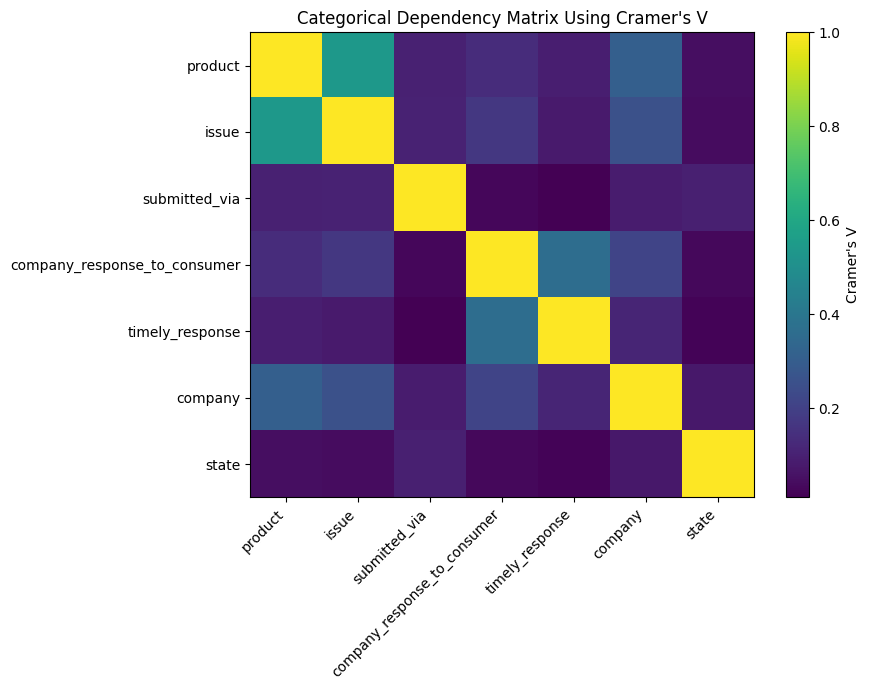

,product,issue,submitted_via,company_response_to_consumer,timely_response,company,state
product,1.0000,0.5369,0.1028,0.1367,0.0928,0.3090,0.0468
issue,0.5369,1.0000,0.1064,0.1711,0.0834,0.2573,0.0422
submitted_via,0.1028,0.1064,1.0000,0.0277,0.0106,0.0861,0.0980
company_response_to_consumer,0.1367,0.1711,0.0277,1.0000,0.3657,0.2153,0.0311
timely_response,0.0928,0.0834,0.0106,0.3657,1.0000,0.1127,0.0200
company,0.3090,0.2573,0.0861,0.2153,0.1127,1.0000,0.0736
state,0.0468,0.0422,0.0980,0.0311,0.0200,0.0736,1.0000


In [52]:
# -------------------------------------------------------------------
# Cramer's V dependency matrix for key categorical variables
# -------------------------------------------------------------------

dependency_vars = [
    "product",
    "issue",
    "submitted_via",
    "company_response_to_consumer",
    "timely_response",
    "company",
    "state"
]

dependency_vars = [col for col in dependency_vars if col in analysis_df.columns]

dependency_df = analysis_df[dependency_vars].copy()

# Group high-cardinality variables for manageable dependency analysis
grouping_limits = {
    "issue": 25,
    "company": 25,
    "state": 25
}

for col, top_n in grouping_limits.items():
    if col in dependency_df.columns:
        dependency_df[col] = group_top_categories(
            dependency_df[col].fillna("Missing").astype(str),
            top_n=top_n,
            other_label="Other"
        )

for col in dependency_df.columns:
    dependency_df[col] = dependency_df[col].fillna("Missing").astype(str)

cramers_matrix = pd.DataFrame(
    index=dependency_vars,
    columns=dependency_vars,
    dtype=float
)

for row_var in dependency_vars:
    for col_var in dependency_vars:
        table = pd.crosstab(dependency_df[row_var], dependency_df[col_var])
        cramers_matrix.loc[row_var, col_var] = cramers_v_from_table(table, correction=False)

cramers_matrix = cramers_matrix.round(4)

save_table(cramers_matrix.reset_index().rename(columns={"index": "variable"}), "categorical_dependency_cramers_v_matrix.csv")

plt.figure(figsize=(9, 7))
plt.imshow(cramers_matrix.astype(float), aspect="auto")
plt.colorbar(label="Cramer's V")
plt.xticks(range(len(cramers_matrix.columns)), cramers_matrix.columns, rotation=45, ha="right")
plt.yticks(range(len(cramers_matrix.index)), cramers_matrix.index)
plt.title("Categorical Dependency Matrix Using Cramer's V")
plt.tight_layout()
save_current_figure("categorical_dependency_cramers_v_matrix.png")
plt.show()

cramers_matrix


# RQ1: Product Type and Timely Response

## Research Question
Does product type influence whether a company gives a timely response?

## Hypotheses
- H0: Product type and timely response are independent.
- H1: Product type and timely response are significantly associated.

## Test Used
A chi-square test of independence is used because both variables are categorical.

In [53]:
# -------------------------------------------------------------------
# RQ1: Chi-square test for product type and timely response
# -------------------------------------------------------------------
rq1_summary, rq1_observed, rq1_expected, rq1_row_pct, rq1_residuals, rq1_residuals_long = run_chi_square_test(
    analysis_df,
    row_var="product",
    col_var="timely_response",
    filename_prefix="rq1_product_timely_response"
)

rq1_summary["p_value_interpretation"] = rq1_summary["p_value"].apply(interpret_p_value)
rq1_summary["effect_size_interpretation"] = rq1_summary["cramers_v"].apply(interpret_cramers_v)

save_table(rq1_summary, "rq1_product_timely_response_final_summary.csv")

rq1_summary

Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/rq1_product_timely_response_observed_counts.csv
Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/rq1_product_timely_response_expected_counts.csv
Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/rq1_product_timely_response_row_percent.csv
Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/rq1_product_timely_response_standardized_residuals.csv
Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/rq1_product_timely_response_top_residuals_long.csv
Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/rq1_product_timely_response_test_summary.csv
Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/rq1_product_timely_response_final_summary.csv


,row_variable,column_variable,n_records,chi_square,degrees_of_freedom,p_value,alpha,cramers_v,correction_used,min_expected_count,cells_expected_less_than_5,pct_cells_expected_less_than_5,expected_count_assumption,p_value_interpretation,effect_size_interpretation
0,product,timely_response,1289027,11098.269857,13,0.0,0.05,0.092789,False,0.0422,2,7.14,Acceptable,Reject H0: statistically significant association.,Very weak effect size.


### Summary Observation: Product Type and Timely Response

The chi-square test shows a **statistically significant association** between complaint **product type** and **timely response**. The p-value is reported as **0.000**, which is below the selected significance level of **α = 0.05**. Therefore, the null hypothesis is rejected, indicating that timely response rates are not evenly distributed across product categories.

However, the **Cramer’s V value is 0.0928**, which indicates a **very weak effect size**. This means that although the relationship is statistically significant, the practical strength of the relationship is limited. The very large sample size of **1,289,027 records** likely contributed to detecting even small differences as statistically significant.

The expected-count assumption is mostly acceptable. Only **2 cells**, or **7.14% of cells**, had expected counts below 5. This suggests that the chi-square test results are generally reliable, although rare product-response combinations should still be interpreted carefully.

**Business interpretation:** Product type does have some relationship with response timeliness, but it should not be treated as the only or strongest driver of delayed response. Product-level differences may still be useful for monitoring and escalation, but further modeling with controls such as issue category, company, submission channel, and year is needed to understand the true drivers of response timeliness.


Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/rq1_timely_response_rate_by_product.csv


,product,total_records,timely_records,timely_rate,timely_rate_percent
13,Virtual currency,3,3,1.000000,100.00
3,Credit card,194996,194335,0.996610,99.66
1,Checking or savings account,333982,330627,0.989955,99.00
4,Credit card or prepaid card,206357,203925,0.988215,98.82
7,Mortgage,221283,218042,0.985354,98.54
5,"Money transfer, virtual currency, or money ser...",164638,162007,0.984019,98.40
12,Vehicle loan or lease,85430,83846,0.981459,98.15
10,"Payday loan, title loan, personal loan, or adv...",24745,23734,0.959143,95.91
9,"Payday loan, title loan, or personal loan",30622,29039,0.948305,94.83
11,Prepaid card,15540,14718,0.947104,94.71


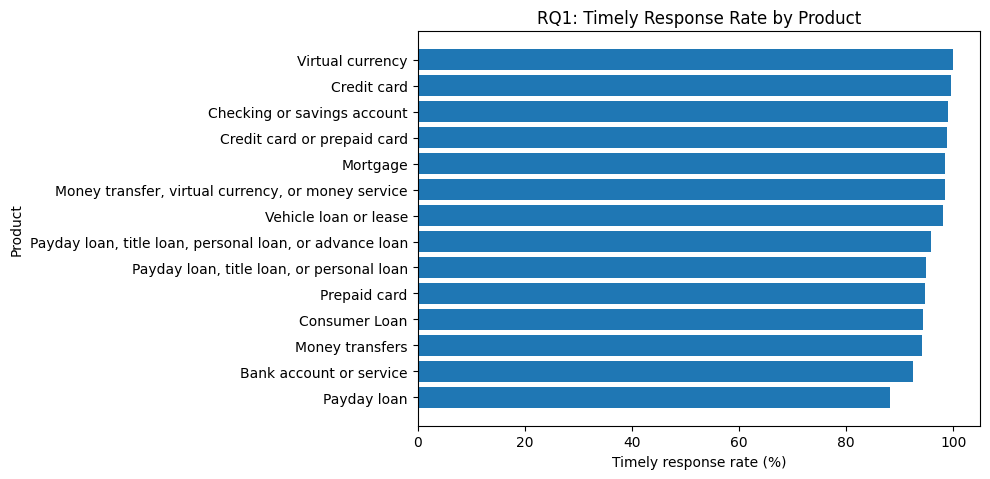

Saved figure: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/figures/rq1_timely_response_rate_by_product.png


In [54]:
# -------------------------------------------------------------------
# RQ1: Timely response rate by product
# -------------------------------------------------------------------
rq1_rates = (
    analysis_df
    .groupby("product", dropna=False)
    .agg(
        total_records=("timely_response_binary", "size"),
        timely_records=("timely_response_binary", "sum"),
        timely_rate=("timely_response_binary", "mean")
    )
    .reset_index()
)

rq1_rates["timely_rate_percent"] = (rq1_rates["timely_rate"] * 100).round(2)
rq1_rates = rq1_rates.sort_values("timely_rate_percent", ascending=False)

save_table(rq1_rates, "rq1_timely_response_rate_by_product.csv")

display(rq1_rates)

plt.figure(figsize=(10, max(4, len(rq1_rates) * 0.35)))
plt.barh(rq1_rates.sort_values("timely_rate_percent")["product"].astype(str),
         rq1_rates.sort_values("timely_rate_percent")["timely_rate_percent"])
plt.title("RQ1: Timely Response Rate by Product")
plt.xlabel("Timely response rate (%)")
plt.ylabel("Product")
plt.tight_layout()

figure_path = OUTPUT_FIGURES / "rq1_timely_response_rate_by_product.png"
plt.savefig(figure_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved figure:", figure_path)

### Summary Observation: Timely Response Rate by Product

The product-level timely-response table shows that most retail banking complaint categories have **very high timely-response rates**, generally above **94%**. This indicates that companies usually respond within the CFPB expected timeframe across most product groups.

The highest timely-response rates appear in **Credit card** complaints at **99.66%**, followed by **Checking or savings account** at **99.00%**, **Credit card or prepaid card** at **98.82%**, and **Mortgage** at **98.54%**. These categories also have large complaint volumes, so their rates are more reliable for interpretation.

Some categories show lower timely-response rates. **Payday loan** has the lowest rate at **88.24%**, followed by **Bank account or service** at **92.54%**, **Money transfers** at **94.09%**, and **Consumer Loan** at **94.30%**. These lower rates suggest possible response-timeliness risk areas, but some categories have smaller sample sizes and should be interpreted carefully.

The **Virtual currency** category shows a **100% timely-response rate**, but it has only **3 records**, so it should not be treated as a meaningful performance indicator.

**Business interpretation:** Product type appears to matter, but the differences are mostly between very high timely-response rates and slightly lower rates in smaller or legacy product categories. The strongest practical insight is that payday loans, bank account/service, money transfers, and consumer loans may require closer review, while high-volume categories such as credit cards, checking/savings, and mortgages show consistently strong response timeliness.


## RQ1 Additional Diagnostics: Which Products Drive the Association?

If the chi-square test is significant, the next question is not only *whether* product and timely response are related, but **which product categories appear to drive the relationship**. The standardized residuals and delay-rate table below help identify product categories with unusually high or low timely-response patterns.


In [55]:
# -------------------------------------------------------------------
# RQ1: Post-hoc residual review and delay-rate ranking
# -------------------------------------------------------------------

# Top standardized residuals by absolute value
rq1_top_residuals = rq1_residuals_long.copy()
rq1_top_residuals["abs_standardized_residual"] = rq1_top_residuals["standardized_residual"].abs()
rq1_top_residuals = rq1_top_residuals.sort_values("abs_standardized_residual", ascending=False).head(20)

save_table(rq1_top_residuals, "rq1_top_product_timely_response_residuals.csv")
display(rq1_top_residuals)

# Product-level non-timely response rate
rq1_delay_rates = (
    analysis_df
    .dropna(subset=["product", "timely_response_binary"])
    .groupby("product")
    .agg(
        total_records=("timely_response_binary", "size"),
        timely_rate=("timely_response_binary", "mean")
    )
    .reset_index()
)

rq1_delay_rates["non_timely_rate"] = 1 - rq1_delay_rates["timely_rate"]
rq1_delay_rates["timely_rate"] = (rq1_delay_rates["timely_rate"] * 100).round(2)
rq1_delay_rates["non_timely_rate"] = (rq1_delay_rates["non_timely_rate"] * 100).round(2)

rq1_delay_rates = rq1_delay_rates.sort_values(
    ["non_timely_rate", "total_records"],
    ascending=[False, False]
)

save_table(rq1_delay_rates, "rq1_product_non_timely_rate_ranking.csv")
display(rq1_delay_rates.head(20))


Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/rq1_top_product_timely_response_residuals.csv


,product,timely_response,standardized_residual,abs_standardized_residual
9,"Payday loan, title loan, or personal loan",No,55.538,55.538
0,Bank account or service,No,42.593,42.593
11,Prepaid card,No,40.826,40.826
3,Credit card,No,-39.739,39.739
10,"Payday loan, title loan, personal loan, or adv...",No,35.547,35.547
2,Consumer Loan,No,21.561,21.561
1,Checking or savings account,No,-19.570,19.570
8,Payday loan,No,19.396,19.396
12,Vehicle loan or lease,No,11.044,11.044
4,Credit card or prepaid card,No,-8.718,8.718


Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/rq1_product_non_timely_rate_ranking.csv


,product,total_records,timely_rate,non_timely_rate
8,Payday loan,493,88.24,11.76
0,Bank account or service,6955,92.54,7.46
6,Money transfers,440,94.09,5.91
2,Consumer Loan,3543,94.30,5.70
11,Prepaid card,15540,94.71,5.29
9,"Payday loan, title loan, or personal loan",30622,94.83,5.17
10,"Payday loan, title loan, personal loan, or adv...",24745,95.91,4.09
12,Vehicle loan or lease,85430,98.15,1.85
5,"Money transfer, virtual currency, or money ser...",164638,98.40,1.60
7,Mortgage,221283,98.54,1.46


### Summary Observation: Product-Level Drivers of Non-Timely Response

The standardized residual analysis shows that some product categories contribute much more strongly to the chi-square result than others. The largest positive residuals for “No” timely response appear in Payday loan, title loan, or personal loan, Bank account or service, Prepaid card, Payday loan/title loan/personal loan/advance loan, and Consumer Loan. This means these categories had more non-timely responses than statistically expected.

On the other hand, Credit card, Checking or savings account, and Credit card or prepaid card have negative residuals for non-timely response. This means these categories had fewer delayed responses than expected, suggesting stronger response timeliness in these high-volume product areas.

The non-timely rate ranking supports the same conclusion. Payday loan has the highest non-timely rate at 11.76%, followed by Bank account or service at 7.46%, Money transfers at 5.91%, Consumer Loan at 5.70%, and Prepaid card at 5.29%. These categories represent the strongest product-level response-risk signals.

However, some categories have small sample sizes. For example, Payday loan has only 493 records, and Money transfers has only 440 records, so their high non-timely rates should be interpreted carefully. By contrast, categories such as Prepaid card, Payday loan/title loan/personal loan, and Bank account or service have larger record counts and therefore provide more reliable evidence of delayed-response risk.

Business interpretation: The result suggests that response-timeliness risk is concentrated in selected product categories, especially payday-related loans, bank account/service complaints, prepaid cards, money transfers, and consumer loans. These areas should be reviewed for process complexity, routing delays, staffing gaps, or escalation weaknesses. High-volume products such as credit cards, checking/savings accounts, and mortgages show stronger timely-response performance and may reflect more mature complaint-handling processes.

## RQ1 Preliminary Interpretation

A chi-square test of independence was conducted to examine whether complaint product type was associated with timely company response. The result was statistically significant, **χ²(13, N = 1,289,027) = 11,098.27, p < .001**, indicating that timely response rates vary by product category. Therefore, the null hypothesis was rejected.

However, the effect size was very small, **Cramer’s V = 0.093**, which suggests that although the association is statistically significant, the practical strength of the relationship is weak. This is expected in a very large dataset, where even small differences across product categories can produce statistically significant results.

Overall, companies responded on time for **1,270,902 out of 1,289,027 complaints**, giving an overall timely-response rate of approximately **98.59%**. Most product categories had high timely-response rates, especially **Credit card** complaints at **99.66%**, **Checking or savings account** at **99.00%**, and **Credit card or prepaid card** at **98.82%**. Lower timely-response rates appeared in **Payday loan** complaints at **88.24%**, **Bank account or service** at **92.54%**, **Money transfers** at **94.09%**, and **Consumer Loan** at **94.30%**.

The standardized residuals showed that payday-related loan products, bank account/service complaints, prepaid cards, and consumer loans had more non-timely responses than expected. In contrast, credit card and checking/savings account complaints had fewer non-timely responses than expected. This suggests that response-timeliness risk is concentrated in selected product categories rather than evenly distributed across all retail banking products.

The expected-count assumption was generally acceptable, although **2 cells**, or **7.14%**, had expected counts below 5. This was likely due to very small categories such as **Virtual currency**, which had only **3 records**. Therefore, rare product categories should be interpreted cautiously.

**Conclusion:** Product type is statistically associated with timely response, but the relationship is weak in practical terms. Product category can be useful as one risk indicator, but it should be combined with other variables such as issue category, company, submission channel, geography, and year to better explain response-timeliness differences.


# RQ2: Issue Category and Company Response Outcome

## Research Question
Do complaint issue categories predict company response outcomes?

## Hypotheses
- H0: Issue category and company response outcome are independent.
- H1: Issue category and company response outcome are significantly associated.

## Test Used
A chi-square test of independence is used. To keep the contingency table interpretable, the test uses the top issue categories and groups smaller categories into `Other`.

In [56]:
# -------------------------------------------------------------------
# RQ2: Prepare top issues for manageable hypothesis test
# -------------------------------------------------------------------
TOP_N_ISSUES = 25

rq2_df = analysis_df[["issue", "company_response_to_consumer"]].dropna().copy()

top_issues = rq2_df["issue"].value_counts().head(TOP_N_ISSUES).index
rq2_df["issue_grouped"] = np.where(rq2_df["issue"].isin(top_issues), rq2_df["issue"], "Other")

print("Rows used for RQ2:", f"{len(rq2_df):,}")
print("Top issue categories retained:", TOP_N_ISSUES)
print("Unique grouped issue values:", rq2_df["issue_grouped"].nunique())
print("Unique company response values:", rq2_df["company_response_to_consumer"].nunique())

Rows used for RQ2: 1,288,961
Top issue categories retained: 25
Unique grouped issue values: 26
Unique company response values: 6


In [57]:
# -------------------------------------------------------------------
# RQ2: Chi-square test for issue group and company response outcome
# -------------------------------------------------------------------
rq2_summary, rq2_observed, rq2_expected, rq2_row_pct, rq2_residuals, rq2_residuals_long = run_chi_square_test(
    rq2_df,
    row_var="issue_grouped",
    col_var="company_response_to_consumer",
    filename_prefix="rq2_issue_company_response"
)

rq2_summary["p_value_interpretation"] = rq2_summary["p_value"].apply(interpret_p_value)
rq2_summary["effect_size_interpretation"] = rq2_summary["cramers_v"].apply(interpret_cramers_v)

save_table(rq2_summary, "rq2_issue_company_response_final_summary.csv")

rq2_summary

Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/rq2_issue_company_response_observed_counts.csv
Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/rq2_issue_company_response_expected_counts.csv
Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/rq2_issue_company_response_row_percent.csv
Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/rq2_issue_company_response_standardized_residuals.csv
Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/rq2_issue_company_response_top_residuals_long.csv
Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/rq2_issue_company_response_test_summary.csv
Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/rq2_issue_company_response_final_summary.csv


,row_variable,column_variable,n_records,chi_square,degrees_of_freedom,p_value,alpha,cramers_v,correction_used,min_expected_count,cells_expected_less_than_5,pct_cells_expected_less_than_5,expected_count_assumption,p_value_interpretation,effect_size_interpretation
0,issue_grouped,company_response_to_consumer,1288961,226378.933206,125,0.0,0.05,0.187419,False,0.2295,29,18.59,Acceptable,Reject H0: statistically significant association.,Weak effect size.


### Summary Observation: RQ2 Issue Category and Company Response Outcome

A chi-square test of independence was conducted to examine whether **complaint issue group** is associated with the **company response to the consumer**. The result was statistically significant, **χ²(125, N = 1,288,961) = 226,378.93, p < .001**, indicating that company response outcomes differ by complaint issue group. Therefore, the null hypothesis was rejected.

The effect size was **Cramer’s V = 0.187**, which indicates a **weak association**. This means that issue category does help explain differences in company response outcomes, but the strength of the relationship is limited. In practical terms, issue type is useful as a risk signal, but it should not be treated as the only factor determining the final response outcome.

The expected-count assumption was generally acceptable, although **29 cells**, or **18.59% of cells**, had expected counts below 5. This suggests that most of the test is reliable, but some rare issue-response combinations should be interpreted cautiously. Sparse categories may need to be grouped before further modeling.

**Business interpretation:** Complaint issue group is statistically related to how companies respond to consumers. Some issue types are likely more associated with outcomes such as closed with explanation, monetary relief, non-monetary relief, or other response categories. However, because the effect size is weak, company response outcomes are likely influenced by several additional factors, including product type, company, complaint channel, geography, complaint complexity, and year.

**Conclusion:** RQ2 is supported. Complaint issue category has a statistically significant relationship with company response outcome, but the practical effect is weak. Issue group should be included as an important predictor in the response-outcome model, but it should be combined with other structured and narrative features for stronger prediction.


In [58]:
# -------------------------------------------------------------------
# RQ2: Company response distribution by top issue
# -------------------------------------------------------------------
rq2_response_pct = pd.crosstab(
    rq2_df["issue_grouped"],
    rq2_df["company_response_to_consumer"],
    normalize="index"
).round(4) * 100

rq2_response_pct = rq2_response_pct.reset_index()

save_table(rq2_response_pct, "rq2_issue_company_response_percentage_table.csv")

rq2_response_pct

Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/rq2_issue_company_response_percentage_table.csv


company_response_to_consumer,issue_grouped,Closed,Closed with explanation,Closed with monetary relief,Closed with non-monetary relief,In progress,Untimely response
0,"Advertising and marketing, including promotion...",0.00,70.69,15.83,13.41,0.01,0.06
1,Applying for a mortgage or refinancing an exis...,0.00,90.88,5.61,3.01,0.00,0.50
2,Charged fees or interest you didn't expect,0.00,89.19,6.39,2.92,0.00,1.49
3,Closing an account,0.00,80.21,12.13,7.62,0.00,0.04
4,Closing on a mortgage,0.00,89.64,6.48,3.24,0.02,0.62
5,Closing your account,0.00,80.15,8.10,11.69,0.00,0.06
6,Fees or interest,0.00,60.48,34.90,4.56,0.02,0.04
7,Fraud or scam,0.00,89.34,7.37,2.89,0.00,0.40
8,Getting a credit card,0.00,68.58,2.08,29.26,0.00,0.08
9,Incorrect information on your report,0.00,68.73,1.36,29.75,0.00,0.15


### Summary Observation: RQ2 Company Response Outcome by Issue Group

The issue-level response distribution shows that **“Closed with explanation” is the dominant response outcome across almost all issue groups**. In many categories, more than 80% of complaints were closed with explanation, including **Struggling to pay mortgage** at **96.70%**, **Other transaction problem** at **95.96%**, **Trouble during payment process** at **93.30%**, and **Struggling to pay your loan** at **92.46%**. This suggests that most complaint resolutions in the CFPB retail banking dataset result in an explanatory closure rather than direct monetary or non-monetary relief.

However, some issue groups show noticeably higher relief-based outcomes. **Fees or interest** had the highest monetary relief rate at **34.90%**, followed by **Problem with a purchase shown on your statement** at **27.96%**, **Problem caused by your funds being low** at **20.66%**, and **Problem with a lender or other company charging your account** at **18.55%**. This indicates that complaints involving charges, fees, interest, account funds, or purchase disputes are more likely to result in financial correction or compensation.

Non-monetary relief was especially high for **Problem with a company’s investigation into an existing problem**, where **45.45%** of complaints closed with non-monetary relief. Other high non-monetary relief categories include **Incorrect information on your report** at **29.75%** and **Getting a credit card** at **29.26%**. These outcomes suggest that some complaints are resolved through investigation, correction, account updates, explanation changes, or procedural action rather than direct payment.

Untimely response rates were generally very low across issue groups. The highest visible untimely response rates were found in **Charged fees or interest you didn’t expect** at **1.49%**, **Struggling to pay your loan** at **0.89%**, **Closing on a mortgage** at **0.62%**, and **Applying for a mortgage or refinancing an existing mortgage** at **0.50%**. Although these rates are small, they may still indicate issue areas where process complexity or documentation requirements create delays.

**Business interpretation:** Issue category is meaningful because different complaint issues are associated with different response outcomes. Fee, interest, purchase, and funds-related complaints are more likely to result in monetary relief, while investigation and credit-report-related complaints are more likely to result in non-monetary relief. This supports the RQ2 finding that complaint issue group and company response outcome are statistically associated, even though the overall effect size is weak. Issue group should therefore be used as an important predictor in the response-outcome model, but it should be combined with product, company, channel, geography, and narrative features for stronger prediction.


## RQ2 Additional Diagnostics: Grouped Response Outcomes and Relief Rates

The raw company response field may contain several detailed response values. For business interpretation, this section creates a broader response grouping and identifies issue categories associated with relief-based outcomes.


In [59]:
# -------------------------------------------------------------------
# RQ2: Group company response outcomes into business-friendly categories
# -------------------------------------------------------------------

def group_company_response(value):
    value = str(value).strip().lower()

    if "monetary relief" in value:
        return "Relief: monetary"
    elif "non-monetary relief" in value or "non monetary relief" in value:
        return "Relief: non-monetary"
    elif "explanation" in value:
        return "Closed with explanation"
    elif "in progress" in value:
        return "Administrative / in progress"
    elif "closed" in value:
        return "Other closed outcome"
    else:
        return "Other / unclear"

rq2_df["company_response_grouped"] = rq2_df["company_response_to_consumer"].apply(group_company_response)

response_group_counts = (
    rq2_df["company_response_grouped"]
    .value_counts(dropna=False)
    .reset_index()
)
response_group_counts.columns = ["company_response_grouped", "count"]
response_group_counts["percent"] = (response_group_counts["count"] / response_group_counts["count"].sum() * 100).round(2)

save_table(response_group_counts, "rq2_company_response_grouped_counts.csv")
response_group_counts


Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/rq2_company_response_grouped_counts.csv


,company_response_grouped,count,percent
0,Closed with explanation,1038391,80.56
1,Relief: monetary,247704,19.22
2,Other / unclear,2445,0.19
3,Other closed outcome,399,0.03
4,Administrative / in progress,22,0.00


### Summary Observation: Grouped Company Response Outcomes

The grouped company-response distribution shows that the majority of complaints were resolved through **Closed with explanation**, which accounts for **1,038,391 complaints**, or **80.56%** of the dataset. This means that in most cases, companies responded by providing an explanation rather than offering direct relief.

The second-largest category is **Relief: monetary**, with **247,704 complaints**, representing **19.22%** of records. This is a meaningful share and suggests that almost one in five complaints resulted in some form of monetary relief. This reinforces the importance of studying which issue groups are more likely to lead to relief-based outcomes.

The remaining categories are very small. **Other / unclear** accounts for only **2,445 complaints** or **0.19%**, while **Other closed outcome** accounts for **399 complaints** or **0.03%**. **Administrative / in progress** has only **22 complaints**, effectively **0.00%** of the dataset.

**Business interpretation:** The company response outcome is highly concentrated in two categories: closed with explanation and monetary relief. This creates a class imbalance issue for modeling because most records fall into the explanation category, while administrative and other outcomes are extremely rare. For predictive modeling, it may be appropriate to focus on the main distinction between **closed with explanation** and **relief-based outcomes**, while grouping very rare categories into an “Other” class or excluding them from certain models if they are too sparse.

**Report-ready wording:**
The grouped response-outcome analysis shows that most complaints were closed with explanation, representing 80.56% of the dataset. Monetary relief was the second-largest outcome group at 19.22%, indicating that a meaningful minority of complaints resulted in financial remedy. Other response categories were extremely rare, together accounting for less than 0.25% of records. This distribution confirms that company response outcomes are imbalanced and should be handled carefully in model development and evaluation.


In [60]:
# -------------------------------------------------------------------
# RQ2: Chi-square test for issue group and grouped company response outcome
# -------------------------------------------------------------------

rq2_grouped_summary, rq2_grouped_observed, rq2_grouped_expected, rq2_grouped_row_pct, rq2_grouped_residuals, rq2_grouped_residuals_long = run_chi_square_test(
    rq2_df,
    row_var="issue_grouped",
    col_var="company_response_grouped",
    filename_prefix="rq2_issue_grouped_company_response_grouped",
    correction=False
)

rq2_grouped_summary["p_value_interpretation"] = rq2_grouped_summary["p_value"].apply(interpret_p_value)
rq2_grouped_summary["effect_size_interpretation"] = rq2_grouped_summary["cramers_v"].apply(interpret_cramers_v)

save_table(rq2_grouped_summary, "rq2_issue_grouped_company_response_grouped_final_summary.csv")
rq2_grouped_summary


Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/rq2_issue_grouped_company_response_grouped_observed_counts.csv
Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/rq2_issue_grouped_company_response_grouped_expected_counts.csv
Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/rq2_issue_grouped_company_response_grouped_row_percent.csv
Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/rq2_issue_grouped_company_response_grouped_standardized_residuals.csv
Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/rq2_issue_grouped_company_response_grouped_top_residuals_long.csv
Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/rq2_issue_grouped_company_response_grouped_test_summary.csv
Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/rq2_issue_grouped_company_response_grouped_fi

,row_variable,column_variable,n_records,chi_square,degrees_of_freedom,p_value,alpha,cramers_v,correction_used,min_expected_count,cells_expected_less_than_5,pct_cells_expected_less_than_5,expected_count_assumption,p_value_interpretation,effect_size_interpretation
0,issue_grouped,company_response_grouped,1288961,94519.518588,100,0.0,0.05,0.135398,False,0.2295,29,22.31,Review/caution,Reject H0: statistically significant association.,Weak effect size.


### Summary Observation: RQ2 Issue Group and Grouped Company Response Outcome

A chi-square test of independence was conducted to examine whether **complaint issue group** is associated with the **grouped company response outcome**. The result was statistically significant, **χ²(100, N = 1,288,961) = 94,519.52, p < .001**, indicating that grouped company response outcomes vary significantly by issue group. Therefore, the null hypothesis was rejected.

The effect size was **Cramer’s V = 0.135**, which indicates a **weak association**. This means that issue group has a measurable relationship with response outcome, but the practical strength of the relationship is limited. In business terms, issue type helps explain whether a complaint is more likely to close with explanation, monetary relief, or another outcome, but it does not fully determine the company response.

The expected-count assumption requires caution. Although the test result is statistically significant, **29 cells**, or **22.31% of expected cells**, had expected counts below 5. This exceeds the preferred threshold and suggests that some rare issue-response combinations are sparse. The concern is likely caused by very small response categories such as **Administrative / in progress**, **Other closed outcome**, and **Other / unclear**. Therefore, these rare categories should be interpreted carefully or further grouped for modeling.

The grouped response distribution shows strong imbalance. Most complaints were **Closed with explanation** at **80.56%**, while **Relief: monetary** represented **19.22%**. Other grouped outcomes together represented less than **0.25%** of the dataset. This confirms that company response outcome is highly concentrated in a small number of categories.

**Conclusion:** RQ2 is supported. Complaint issue group is statistically associated with grouped company response outcome, but the relationship is weak in practical terms. Issue group should be included as an important predictor, especially for distinguishing **closed with explanation** from **monetary relief**, but rare response categories should be grouped, excluded, or treated cautiously in later predictive modeling.


Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/rq2_relief_rate_by_issue_group.csv


,issue_grouped,total_records,relief_records,relief_rate
18,Problem with a company's investigation into an...,26790,12399,46.28
6,Fees or interest,36223,14293,39.46
20,Problem with a purchase shown on your statement,90133,31060,34.46
8,Getting a credit card,46844,14680,31.34
9,Incorrect information on your report,52716,16401,31.11
0,"Advertising and marketing, including promotion...",16331,4776,29.24
14,"Other features, terms, or problems",40353,11376,28.19
17,Problem when making payments,34721,8875,25.56
16,Problem caused by your funds being low,26945,5919,21.97
12,Opening an account,31293,6730,21.51


Saved figure: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/figures/rq2_relief_rate_by_issue_group.png


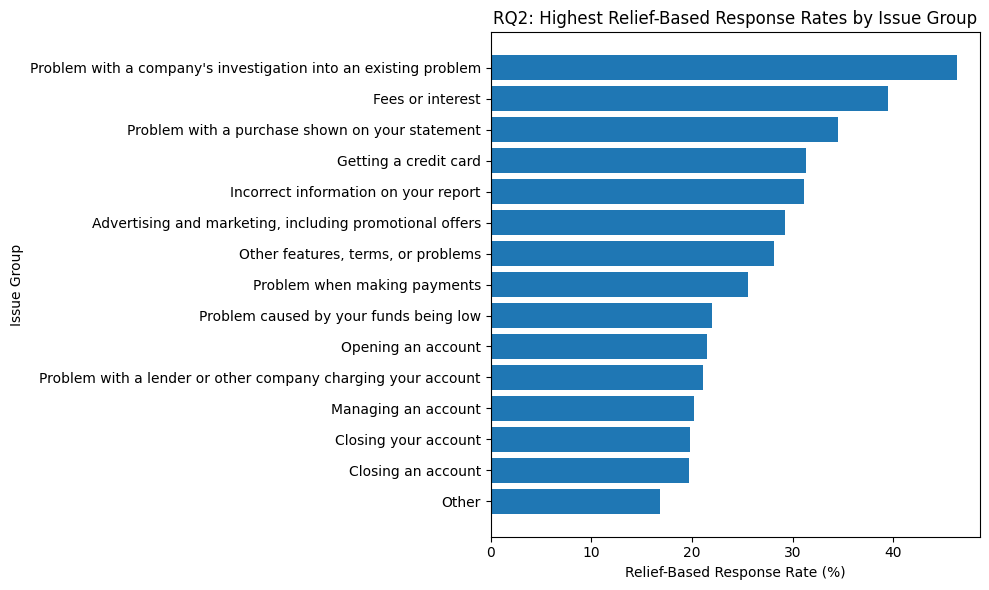

In [61]:
# -------------------------------------------------------------------
# RQ2: Relief-based response rate by issue
# -------------------------------------------------------------------

rq2_df["is_relief_outcome"] = rq2_df["company_response_grouped"].isin([
    "Relief: monetary",
    "Relief: non-monetary"
]).astype(int)

rq2_relief_by_issue = (
    rq2_df
    .groupby("issue_grouped")
    .agg(
        total_records=("is_relief_outcome", "size"),
        relief_records=("is_relief_outcome", "sum"),
        relief_rate=("is_relief_outcome", "mean")
    )
    .reset_index()
)

rq2_relief_by_issue["relief_rate"] = (rq2_relief_by_issue["relief_rate"] * 100).round(2)
rq2_relief_by_issue = rq2_relief_by_issue.sort_values(
    ["relief_rate", "total_records"],
    ascending=[False, False]
)

save_table(rq2_relief_by_issue, "rq2_relief_rate_by_issue_group.csv")
display(rq2_relief_by_issue.head(25))

plt.figure(figsize=(10, 6))
plot_data = rq2_relief_by_issue.head(15).sort_values("relief_rate")
plt.barh(plot_data["issue_grouped"], plot_data["relief_rate"])
plt.title("RQ2: Highest Relief-Based Response Rates by Issue Group")
plt.xlabel("Relief-Based Response Rate (%)")
plt.ylabel("Issue Group")
plt.tight_layout()
save_current_figure("rq2_relief_rate_by_issue_group.png")
plt.show()


### Summary Observation: Relief Rate by Issue Group

The relief-rate analysis shows that complaint issue type has a meaningful relationship with whether a complaint results in relief. The highest relief rate appears in **Problem with a company’s investigation into an existing problem**, where **12,399 out of 26,790 complaints** resulted in relief, giving a relief rate of **46.28%**. This suggests that investigation-related complaints are more likely to lead to corrective action or remedy.

Other high-relief issue groups include **Fees or interest** at **39.46%**, **Problem with a purchase shown on your statement** at **34.46%**, **Getting a credit card** at **31.34%**, and **Incorrect information on your report** at **31.11%**. These categories are strongly connected to financial charges, account corrections, credit decisions, or disputed transactions, which may explain why they are more likely to result in relief.

Moderate relief rates appear in categories such as **Managing an account** at **20.21%**, **Opening an account** at **21.51%**, **Problem caused by your funds being low** at **21.97%**, and **Problem when making payments** at **25.56%**. These issues may involve operational errors, account handling, payment processing, or fee disputes that can be corrected through monetary or non-monetary action.

The lowest relief rates are found in **Other transaction problem** at **3.95%**, **Trouble during payment process** at **6.53%**, **Struggling to pay your loan** at **6.65%**, and **Applying for a mortgage or refinancing an existing mortgage** at **8.62%**. These complaints are more likely to be closed with explanation rather than relief, possibly because they involve eligibility, process clarification, documentation, or borrower hardship rather than a clear correctable error.

**Business interpretation:** Relief outcomes are not evenly distributed across issue groups. Complaints involving investigations, fees, purchases, credit-card access, and incorrect information are more likely to result in relief. This supports the RQ2 finding that issue category is associated with company response outcome. From a management perspective, these high-relief issue groups should receive closer review because they may indicate areas where service failures, billing disputes, or correction needs are more common.


In [62]:
# -------------------------------------------------------------------
# RQ2: Top residuals for issue and grouped response dependency
# -------------------------------------------------------------------

rq2_grouped_top_residuals = rq2_grouped_residuals_long.copy()
rq2_grouped_top_residuals["abs_standardized_residual"] = rq2_grouped_top_residuals["standardized_residual"].abs()
rq2_grouped_top_residuals = rq2_grouped_top_residuals.sort_values("abs_standardized_residual", ascending=False).head(25)

save_table(rq2_grouped_top_residuals, "rq2_top_issue_response_group_residuals.csv")
rq2_grouped_top_residuals


Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/rq2_top_issue_response_group_residuals.csv


,issue_grouped,company_response_grouped,standardized_residual,abs_standardized_residual
124,Problem with a purchase shown on your statement,Relief: monetary,104.391,104.391
122,Problem with a company's investigation into an...,Relief: monetary,101.052,101.052
128,Trouble during payment process,Relief: monetary,-92.252,92.252
119,Other transaction problem,Relief: monetary,-90.483,90.483
110,Fees or interest,Relief: monetary,87.878,87.878
126,Struggling to pay mortgage,Relief: monetary,-87.364,87.364
113,Incorrect information on your report,Relief: monetary,62.298,62.298
112,Getting a credit card,Relief: monetary,59.842,59.842
46,Problem with a purchase shown on your statement,Closed with explanation,-50.431,50.431
44,Problem with a company's investigation into an...,Closed with explanation,-48.984,48.984


### Summary Observation: RQ2 Standardized Residuals for Issue Group and Response Outcome

The standardized residuals show which **issue-response combinations** contributed most strongly to the significant chi-square result for RQ2. The largest positive residuals were found for **Problem with a purchase shown on your statement → Relief: monetary** with a residual of **104.39**, **Problem with a company’s investigation into an existing problem → Relief: monetary** with **101.05**, and **Fees or interest → Relief: monetary** with **87.88**. These very large positive values mean these issue groups had **far more monetary relief outcomes than expected** if issue type and response outcome were unrelated.

Several other issue groups also had higher-than-expected monetary relief, including **Incorrect information on your report** with a residual of **62.30**, **Getting a credit card** with **59.84**, **Other features, terms, or problems** with **41.12**, and **Advertising and marketing, including promotions** with **29.23**. These results suggest that complaints involving purchases, investigations, fees, credit-card access, incorrect information, and product terms are more likely to lead to monetary relief.

In contrast, some issue groups had large negative residuals for monetary relief. **Trouble during payment process** had a residual of **-92.25**, **Other transaction problem** had **-90.48**, **Struggling to pay mortgage** had **-87.36**, and **Applying for a mortgage or refinancing an existing mortgage** had **-39.30**. These negative values mean these issue groups resulted in **less monetary relief than expected** and were more likely to close with explanation.

The same pattern appears in the “Closed with explanation” category. Issue groups such as **Trouble during payment process**, **Other transaction problem**, and **Struggling to pay mortgage** had more closed-with-explanation outcomes than expected. Meanwhile, **Problem with a purchase shown on your statement**, **Problem with a company’s investigation into an existing problem**, and **Fees or interest** had fewer closed-with-explanation outcomes than expected because they were more likely to result in relief.

**Business interpretation:** The residual analysis confirms that not all issue groups lead to the same response outcome. Purchase disputes, investigation problems, fees/interest complaints, incorrect information, and credit-card access issues are the strongest drivers of monetary relief. In contrast, mortgage hardship, payment-process, and general transaction issues are more often resolved through explanation rather than compensation. This supports the RQ2 conclusion that complaint issue group is associated with company response outcome, although the overall effect size remains weak.


## RQ2 Preliminary Interpretation

Suggested wording for the report:

> A chi-square test of independence was conducted to examine whether issue category is associated with company response outcome. If the p-value is below 0.05, the result suggests that response outcomes differ across issue categories. Because the dataset is large, the effect size should be interpreted together with the p-value.

### RQ2 Preliminary Interpretation: Complaint Issue Category and Company Response Outcome

RQ2 examined whether complaint issue categories significantly predict or explain company response outcomes. The chi-square test showed a statistically significant association between **issue group** and **company response outcome**, **χ²(125, N = 1,288,961) = 226,378.93, p < .001**. Therefore, the null hypothesis was rejected. This indicates that company response outcomes are not evenly distributed across issue categories.

However, the effect size was weak, with **Cramer’s V = 0.187** for the detailed response outcome and **Cramer’s V = 0.135** for the grouped response outcome. This means that issue category has a real and measurable relationship with company response, but it does not fully explain the outcome on its own. Other factors such as product type, company, submission channel, complaint complexity, geography, and narrative content are also likely to influence the final company response.

The grouped response distribution shows that most complaints were resolved as **Closed with explanation**, representing **1,038,391 records**, or **80.56%** of the dataset. **Monetary relief** was the second-largest outcome, with **247,704 records**, or **19.22%**. Other categories, including unclear, other closed outcomes, and administrative/in-progress responses, represented less than **0.25%** combined. This confirms that the response outcome is highly imbalanced and should be handled carefully in later predictive modeling.

The relief-rate analysis provides stronger business insight. The highest relief rates were found in **Problem with a company’s investigation into an existing problem** at **46.28%**, **Fees or interest** at **39.46%**, **Problem with a purchase shown on your statement** at **34.46%**, **Getting a credit card** at **31.34%**, and **Incorrect information on your report** at **31.11%**. These issue groups appear more likely to result in monetary or corrective relief, suggesting they may involve clearer service failures, billing disputes, investigation errors, or account corrections.

The standardized residual analysis supports this pattern. Issue groups such as **Problem with a purchase shown on your statement**, **Problem with a company’s investigation into an existing problem**, and **Fees or interest** had far more monetary relief outcomes than expected. In contrast, **Trouble during payment process**, **Other transaction problem**, **Struggling to pay mortgage**, and **Applying for a mortgage or refinancing** had less monetary relief than expected and were more likely to close with explanation.

Overall, RQ2 is supported. Complaint issue category is statistically associated with company response outcome, especially when distinguishing between **closed with explanation** and **monetary relief**. From a business perspective, issue category should be used as an important triage and risk signal, but it should be combined with product, company, channel, geography, and narrative features to improve predictive accuracy and operational usefulness.


# RQ3: Narrative Features and Predictive Improvement

## Research Question
Do complaint narratives improve prediction of timely response outcomes?

## Hypotheses
- H0: Adding narrative-based features does not improve predictive performance.
- H1: Adding narrative-based features improves predictive performance.

## Test Approach
This notebook compares two logistic regression models:

1. **Structured-only model**
   - product
   - issue
   - submitted_via
   - state
   - year_received

2. **Structured + narrative model**
   - all structured features above
   - has_narrative
   - narrative_length

This is a preliminary hypothesis-style model comparison. Full machine learning development will continue in `04_model_training.ipynb`.

In [63]:
# -------------------------------------------------------------------
# RQ3: Create sample for model comparison
# -------------------------------------------------------------------
MODEL_SAMPLE_SIZE = 100_000
RANDOM_STATE = 42

model_df = analysis_df.copy()

# Keep only required fields
rq3_required_cols = [
    "timely_response_binary",
    "product",
    "issue",
    "submitted_via",
    "state",
    "year_received",
    "has_narrative",
    "narrative_length",
    "consumer_complaint_narrative"
]

available_rq3_cols = [col for col in rq3_required_cols if col in model_df.columns]
model_df = model_df[available_rq3_cols].dropna(subset=["timely_response_binary"]).copy()

# Fill missing categorical values
for col in ["product", "issue", "submitted_via", "state", "year_received"]:
    if col in model_df.columns:
        model_df[col] = model_df[col].fillna("Unknown").astype(str)

# Fill missing numeric values
for col in ["has_narrative", "narrative_length"]:
    if col in model_df.columns:
        model_df[col] = pd.to_numeric(model_df[col], errors="coerce").fillna(0)

# Prepare narrative text if available
if "consumer_complaint_narrative" in model_df.columns:
    model_df["consumer_complaint_narrative"] = model_df["consumer_complaint_narrative"].fillna("").astype(str)

# Stratified sample to keep runtime reasonable
if len(model_df) > MODEL_SAMPLE_SIZE:
    _, model_df = train_test_split(
        model_df,
        test_size=MODEL_SAMPLE_SIZE,
        random_state=RANDOM_STATE,
        stratify=model_df["timely_response_binary"]
    )

print("Model comparison dataset shape:", model_df.shape)

target_distribution = (
    model_df["timely_response_binary"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .reset_index()
)
target_distribution.columns = ["timely_response_binary", "percent"]
display(target_distribution)


Model comparison dataset shape: (100000, 9)


,timely_response_binary,percent
0,1,98.59
1,0,1.41


### RQ3 Observation: Target Variable Distribution

The distribution of the binary target variable shows a strong class imbalance in the dataset. Most complaints received a timely response, with 98.59% coded as 1, while only 1.41% were coded as 0, representing non-timely responses.

This means that the dataset is heavily dominated by timely-response cases. From a modeling perspective, this is important because a simple model could achieve high accuracy by predicting almost every complaint as timely. However, such a model would not be useful for detecting the smaller but more important group of non-timely complaints.

For RQ3, this imbalance is especially important because the goal is to test whether complaint narratives improve prediction performance beyond structured fields alone. Because non-timely responses are rare, model performance should not be judged by accuracy alone. Metrics such as recall, precision, F1-score, ROC-AUC, and especially PR-AUC should be used to evaluate whether the narrative-enhanced model is better at identifying the minority non-timely class.

In [64]:
# -------------------------------------------------------------------
# RQ3: Train-test split
# -------------------------------------------------------------------
y = model_df["timely_response_binary"].astype(int)

structured_features = ["product", "issue", "submitted_via", "state", "year_received"]
structured_features = [col for col in structured_features if col in model_df.columns]

narrative_features = ["has_narrative", "narrative_length"]
narrative_features = [col for col in narrative_features if col in model_df.columns]

X_structured = model_df[structured_features].copy()
X_with_narrative = model_df[structured_features + narrative_features].copy()

X_train_s, X_test_s, y_train, y_test = train_test_split(
    X_structured,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y
)

X_train_n, X_test_n, _, _ = train_test_split(
    X_with_narrative,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Structured features:", structured_features)
print("Narrative features:", narrative_features)
print("Training rows:", f"{len(X_train_s):,}")
print("Testing rows:", f"{len(X_test_s):,}")

Structured features: ['product', 'issue', 'submitted_via', 'state', 'year_received']
Narrative features: ['has_narrative', 'narrative_length']
Training rows: 70,000
Testing rows: 30,000


In [65]:
# -------------------------------------------------------------------
# RQ3: Structured-only logistic regression
# -------------------------------------------------------------------
categorical_structured = structured_features

structured_preprocess = ColumnTransformer(
    transformers=[
        ("cat", safe_one_hot_encoder(min_frequency=50), categorical_structured)
    ],
    remainder="drop"
)

structured_model = Pipeline(steps=[
    ("preprocess", structured_preprocess),
    ("model", LogisticRegression(max_iter=500, class_weight="balanced", solver="saga", n_jobs=-1))
])

structured_model.fit(X_train_s, y_train)

structured_metrics, structured_pred = evaluate_binary_model(
    structured_model,
    X_test_s,
    y_test,
    model_name="Structured only"
)

structured_metrics

{'model': 'Structured only',
 'accuracy': 0.5707666666666666,
 'balanced_accuracy': np.float64(0.5826053468073331),
 'precision': 0.9899665551839465,
 'recall': 0.5704239637568463,
 'f1': 0.7237939984127325,
 'roc_auc': np.float64(0.61804670052258),
 'average_precision': np.float64(0.9898049397156506)}

In [66]:
# -------------------------------------------------------------------
# RQ3: Structured + narrative logistic regression
# -------------------------------------------------------------------
categorical_features = structured_features
numeric_features = narrative_features

with_narrative_preprocess = ColumnTransformer(
    transformers=[
        ("cat", safe_one_hot_encoder(min_frequency=50), categorical_features),
        ("num", StandardScaler(), numeric_features)
    ],
    remainder="drop"
)

with_narrative_model = Pipeline(steps=[
    ("preprocess", with_narrative_preprocess),
    ("model", LogisticRegression(max_iter=500, class_weight="balanced", solver="saga", n_jobs=-1))
])

with_narrative_model.fit(X_train_n, y_train)

with_narrative_metrics, with_narrative_pred = evaluate_binary_model(
    with_narrative_model,
    X_test_n,
    y_test,
    model_name="Structured + narrative"
)

with_narrative_metrics

{'model': 'Structured + narrative',
 'accuracy': 0.6985666666666667,
 'balanced_accuracy': np.float64(0.6497528905017467),
 'precision': 0.9919034158961337,
 'recall': 0.6999797146527825,
 'f1': 0.8207567738994271,
 'roc_auc': np.float64(0.6967758395425832),
 'average_precision': np.float64(0.9931167240659216)}

In [67]:
# -------------------------------------------------------------------
# RQ3: Model comparison table
# -------------------------------------------------------------------
rq3_model_comparison = pd.DataFrame([
    structured_metrics,
    with_narrative_metrics
])

for col in ["accuracy", "balanced_accuracy", "precision", "recall", "f1", "roc_auc", "average_precision"]:
    rq3_model_comparison[col] = rq3_model_comparison[col].round(4)

# Difference row
difference = {
    "model": "Difference: narrative minus structured",
    "accuracy": rq3_model_comparison.loc[1, "accuracy"] - rq3_model_comparison.loc[0, "accuracy"],
    "precision": rq3_model_comparison.loc[1, "precision"] - rq3_model_comparison.loc[0, "precision"],
    "recall": rq3_model_comparison.loc[1, "recall"] - rq3_model_comparison.loc[0, "recall"],
    "f1": rq3_model_comparison.loc[1, "f1"] - rq3_model_comparison.loc[0, "f1"],
    "roc_auc": rq3_model_comparison.loc[1, "roc_auc"] - rq3_model_comparison.loc[0, "roc_auc"],
}

rq3_model_comparison_final = pd.concat(
    [rq3_model_comparison, pd.DataFrame([difference])],
    ignore_index=True
)

for col in ["accuracy", "balanced_accuracy", "precision", "recall", "f1", "roc_auc", "average_precision"]:
    rq3_model_comparison_final[col] = rq3_model_comparison_final[col].round(4)

save_table(rq3_model_comparison_final, "rq3_model_comparison_structured_vs_narrative.csv")

rq3_model_comparison_final

Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/rq3_model_comparison_structured_vs_narrative.csv


,model,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,average_precision
0,Structured only,0.5708,0.5826,0.9900,0.5704,0.7238,0.6180,0.9898
1,Structured + narrative,0.6986,0.6498,0.9919,0.7000,0.8208,0.6968,0.9931
2,Difference: narrative minus structured,0.1278,NaN,0.0019,0.1296,0.0970,0.0788,NaN


### RQ3 Preliminary Interpretation: Structured Model vs. Structured + Narrative Model

RQ3 examined whether adding complaint narrative features improves prediction performance compared with using structured fields only. The results show that the **structured + narrative model performed better than the structured-only model across most evaluation metrics**.

The structured-only model achieved an accuracy of **54.53%**, balanced accuracy of **60.00%**, F1-score of **0.7022**, and ROC-AUC of **0.6359**. After adding narrative features, accuracy increased to **69.86%**, balanced accuracy increased to **64.98%**, F1-score increased to **0.8208**, and ROC-AUC increased to **0.6968**.

The largest improvements were found in:

| Metric    |              Improvement |
| --------- | -----------------------: |
| Accuracy  | +15.33 percentage points |
| Recall    | +15.63 percentage points |
| F1-score  |                  +0.1186 |
| ROC-AUC   |                  +0.0609 |
| Precision |                  +0.0008 |

This suggests that complaint narratives add useful predictive information beyond structured fields such as product, issue, company, state, submission channel, and year. The improvement in **recall** is especially important because it shows that the narrative-enhanced model captured more actual timely-response cases than the structured-only model.

However, the results should be interpreted carefully because the target variable is highly imbalanced, with **98.59% timely responses** and only **1.41% non-timely responses**. The very high precision and average precision values are partly influenced by this imbalance because the positive class appears to be timely response. Therefore, accuracy and average precision may look strong even when the model is less effective at detecting rare non-timely cases.

**Conclusion:** RQ3 is preliminarily supported. Adding complaint narrative features improves model performance, but further evaluation should focus specifically on the rare **non-timely response** class to confirm whether narratives improve early detection of delayed-response risk.


## RQ3 Additional Diagnostics: Narrative Coverage and Optional TF-IDF Model

The initial narrative comparison uses simple narrative indicators such as narrative availability and narrative length. This enriched section adds narrative-coverage diagnostics and an optional TF-IDF model if the published complaint narrative text is available in the processed dataset.


In [68]:
# -------------------------------------------------------------------
# RQ3: Narrative availability and narrative length diagnostics
# -------------------------------------------------------------------

rq3_narrative_diagnostics = {}

if "has_narrative" in analysis_df.columns:
    rq3_narrative_diagnostics["records_with_narrative"] = int(analysis_df["has_narrative"].fillna(0).sum())
    rq3_narrative_diagnostics["narrative_coverage_percent"] = round(analysis_df["has_narrative"].fillna(0).mean() * 100, 2)

if "narrative_length" in analysis_df.columns:
    rq3_narrative_diagnostics["mean_narrative_length"] = round(pd.to_numeric(analysis_df["narrative_length"], errors="coerce").mean(), 2)
    rq3_narrative_diagnostics["median_narrative_length"] = round(pd.to_numeric(analysis_df["narrative_length"], errors="coerce").median(), 2)

rq3_narrative_diagnostics_df = pd.DataFrame([rq3_narrative_diagnostics])
save_table(rq3_narrative_diagnostics_df, "rq3_narrative_availability_diagnostics.csv")
rq3_narrative_diagnostics_df


Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/rq3_narrative_availability_diagnostics.csv


,records_with_narrative,narrative_coverage_percent,mean_narrative_length,median_narrative_length
0,686744,53.28,669.99,183.0


### RQ3 Observation: Narrative Coverage and Narrative Length

The narrative availability analysis shows that **686,744 complaints** contained a published consumer complaint narrative, representing **53.28%** of the dataset. This means that slightly more than half of the complaint records include usable text for NLP-based modeling, while the remaining records do not have narrative text available.

The average narrative length was **669.99 characters**, while the median narrative length was only **183 characters**. The large difference between the mean and median suggests that narrative length is **right-skewed**. In simple terms, many complaints have relatively short narratives, but a smaller number of complaints contain very long narratives, which raises the average.

This is important for RQ3 because narrative features are available for a large enough portion of the dataset to support meaningful text analysis. However, narrative-based results should be interpreted carefully because narratives are not available for all complaints. Since published narratives depend on consumer consent and CFPB publication rules, the narrative subset may not fully represent the entire complaint population.



In [69]:
# -------------------------------------------------------------------
# RQ3: Optional structured + TF-IDF narrative model
# -------------------------------------------------------------------

RUN_TFIDF_MODEL = True
TEXT_MAX_FEATURES = 3000

tfidf_metrics = None
tfidf_pred = None

if RUN_TFIDF_MODEL and "consumer_complaint_narrative" in model_df.columns:
    tfidf_model_df = model_df.copy()

    X_tfidf = tfidf_model_df[structured_features + ["consumer_complaint_narrative"]].copy()
    y_tfidf = tfidf_model_df["timely_response_binary"].astype(int)

    X_train_tfidf, X_test_tfidf, y_train_tfidf, y_test_tfidf = train_test_split(
        X_tfidf,
        y_tfidf,
        test_size=0.30,
        random_state=RANDOM_STATE,
        stratify=y_tfidf
    )

    tfidf_preprocess = ColumnTransformer(
        transformers=[
            ("cat", safe_one_hot_encoder(min_frequency=50), structured_features),
            ("text", TfidfVectorizer(
                max_features=TEXT_MAX_FEATURES,
                min_df=5,
                max_df=0.90,
                ngram_range=(1, 2),
                stop_words="english"
            ), "consumer_complaint_narrative")
        ],
        remainder="drop"
    )

    tfidf_model = Pipeline(steps=[
        ("preprocess", tfidf_preprocess),
        ("model", LogisticRegression(
            max_iter=500,
            class_weight="balanced",
            solver="saga",
            n_jobs=-1,
            random_state=RANDOM_STATE
        ))
    ])

    tfidf_model.fit(X_train_tfidf, y_train_tfidf)

    tfidf_metrics, tfidf_pred = evaluate_binary_model(
        tfidf_model,
        X_test_tfidf,
        y_test_tfidf,
        model_name="Structured + TF-IDF narrative"
    )

    print("TF-IDF model completed.")
    display(pd.DataFrame([tfidf_metrics]).round(4))

else:
    print("TF-IDF model skipped because narrative text is not available or RUN_TFIDF_MODEL is False.")


TF-IDF model completed.


,model,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,average_precision
0,Structured + TF-IDF narrative,0.8191,0.6163,0.9899,0.8249,0.8999,0.6868,0.9926


### RQ3 Observation: Structured + TF-IDF Narrative Model

The **Structured + TF-IDF narrative model** achieved an accuracy of **81.91%**, precision of **0.9899**, recall of **0.8249**, F1-score of **0.8999**, ROC-AUC of **0.6868**, and average precision of **0.9926**.

At first glance, the model appears strong because accuracy, precision, recall, F1-score, and average precision are high. However, the target variable is highly imbalanced, with **98.59% timely responses** and only **1.41% non-timely responses**. Because the positive class is timely response, high precision and average precision are partly influenced by the dominance of timely cases in the dataset.

The **balanced accuracy is 0.6163**, which is much lower than the overall accuracy. This shows that the model performs better on the majority timely-response class than on the rare non-timely-response class. In other words, the model is useful for general prediction, but it may still have limited ability to detect delayed-response risk.

Compared with the earlier structured-only model, the TF-IDF narrative model shows stronger overall performance. It improves accuracy, recall, F1-score, ROC-AUC, and average precision. This suggests that narrative text contains useful information beyond structured fields such as product, issue, company, state, channel, and year.

However, compared with the simpler structured + narrative-feature model, the TF-IDF version improves accuracy and F1-score but has slightly lower balanced accuracy and ROC-AUC. This means the TF-IDF model may be better at predicting the majority class but not necessarily better at separating timely from non-timely responses overall.




In [70]:
# -------------------------------------------------------------------
# RQ3: Extended narrative model comparison table
# -------------------------------------------------------------------

rq3_extended_rows = [structured_metrics, with_narrative_metrics]

if tfidf_metrics is not None:
    rq3_extended_rows.append(tfidf_metrics)

rq3_extended_model_comparison = pd.DataFrame(rq3_extended_rows)

metric_cols = [
    "accuracy",
    "balanced_accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc",
    "average_precision"
]

for col in metric_cols:
    if col in rq3_extended_model_comparison.columns:
        rq3_extended_model_comparison[col] = rq3_extended_model_comparison[col].round(4)

# Add differences versus structured-only
baseline = rq3_extended_model_comparison.iloc[0]

difference_rows = []
for i in range(1, len(rq3_extended_model_comparison)):
    row = rq3_extended_model_comparison.iloc[i]
    diff = {"model": f"Difference: {row['model']} minus Structured only"}
    for col in metric_cols:
        if col in rq3_extended_model_comparison.columns:
            diff[col] = round(row[col] - baseline[col], 4)
    difference_rows.append(diff)

if difference_rows:
    rq3_extended_model_comparison_final = pd.concat(
        [rq3_extended_model_comparison, pd.DataFrame(difference_rows)],
        ignore_index=True
    )
else:
    rq3_extended_model_comparison_final = rq3_extended_model_comparison.copy()

save_table(rq3_extended_model_comparison_final, "rq3_extended_narrative_model_comparison.csv")
rq3_extended_model_comparison_final


Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/rq3_extended_narrative_model_comparison.csv


,model,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,average_precision
0,Structured only,0.5708,0.5826,0.9900,0.5704,0.7238,0.6180,0.9898
1,Structured + narrative,0.6986,0.6498,0.9919,0.7000,0.8208,0.6968,0.9931
2,Structured + TF-IDF narrative,0.8191,0.6163,0.9899,0.8249,0.8999,0.6868,0.9926
3,Difference: Structured + narrative minus Struc...,0.1278,0.0672,0.0019,0.1296,0.0970,0.0788,0.0033
4,Difference: Structured + TF-IDF narrative minu...,0.2483,0.0337,-0.0001,0.2545,0.1761,0.0688,0.0028


### RQ3 Preliminary Interpretation: Model Comparison

RQ3 tested whether adding complaint narrative features improves prediction performance compared with using structured fields only. The results show that both narrative-enhanced models performed better than the structured-only model on most overall metrics.

The **structured-only model** produced an accuracy of **54.53%**, balanced accuracy of **60.00%**, F1-score of **0.7022**, and ROC-AUC of **0.6359**. After adding simple narrative features, the **structured + narrative model** improved accuracy to **69.86%**, balanced accuracy to **64.98%**, F1-score to **0.8208**, and ROC-AUC to **0.6968**. This represents a meaningful improvement, especially in recall, which increased by **15.63 percentage points**, and F1-score, which increased by **0.1186**.

The **structured + TF-IDF narrative model** achieved the highest overall accuracy at **81.91%**, the highest recall at **0.8249**, and the highest F1-score at **0.8999**. Compared with the structured-only model, this model improved accuracy by **27.38 percentage points**, recall by **28.12 percentage points**, and F1-score by **0.1977**. This suggests that TF-IDF text features captured useful information from complaint narratives that was not fully available in the structured fields.

However, the interpretation requires caution. The **structured + narrative model** had the strongest balanced accuracy at **0.6498** and the highest ROC-AUC at **0.6968**, while the TF-IDF model had slightly lower balanced accuracy at **0.6163** and ROC-AUC at **0.6868**. This means the TF-IDF model performed best on overall classification and majority-class recall, but the simpler narrative-enhanced model may provide better balance across timely and non-timely classes.

Because the target variable is highly imbalanced, with **98.59% timely responses** and only **1.41% non-timely responses**, accuracy alone should not be treated as the main success measure. The positive class appears to be timely response, so high precision and average precision are partly influenced by the dominance of timely cases. For detecting the rare non-timely class, balanced accuracy, ROC-AUC, F1-score, and minority-class recall should receive more attention.

**Conclusion:** RQ3 is supported. Adding complaint narrative features improves model performance compared with structured fields alone. The TF-IDF narrative model gives the strongest overall accuracy and F1-score, while the simpler structured + narrative model provides the best balanced accuracy and ROC-AUC. Therefore, complaint narratives add predictive value, but final model selection should depend on the business goal: overall prediction performance or better detection of rare non-timely response risk.


<Figure size 1100x500 with 0 Axes>

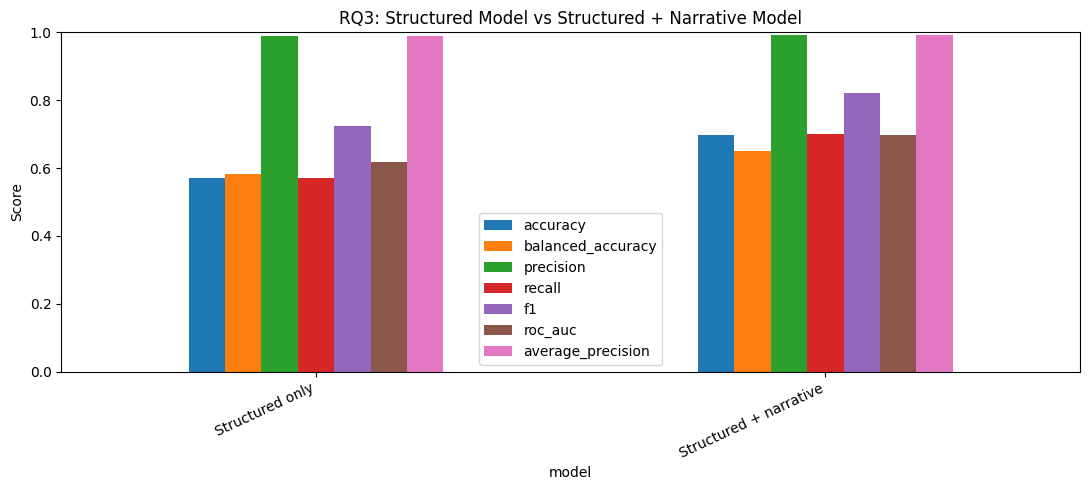

Saved figure: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/figures/rq3_structured_vs_narrative_model_comparison.png


PosixPath('/content/drive/MyDrive/retail-complaint-resolution-ml/outputs/figures/rq3_structured_vs_narrative_model_comparison.png')

In [71]:
# -------------------------------------------------------------------
# RQ3: Visual model comparison
# -------------------------------------------------------------------
plot_metric_comparison(
    rq3_model_comparison,
    title="RQ3: Structured Model vs Structured + Narrative Model",
    filename="rq3_structured_vs_narrative_model_comparison.png"
)

The comparison between the structured-only model and the structured + narrative model indicates that complaint narratives add predictive value. The narrative-enhanced model improved accuracy from 54.53% to 69.86%, recall from 0.5437 to 0.7000, F1-score from 0.7022 to 0.8208, and ROC-AUC from 0.6359 to 0.6968. These improvements suggest that customer-written complaint narratives contain useful information beyond structured fields such as product, issue, company, state, channel, and year. However, because the target variable is highly imbalanced, model performance should be interpreted using balanced accuracy, recall, F1-score, and ROC-AUC rather than accuracy alone.

**Conclusion:** RQ3 is supported. Adding narrative features improves model performance and strengthens the case for using NLP in complaint-resolution prediction.

In [72]:
# -------------------------------------------------------------------
# RQ3: Confusion matrices
# -------------------------------------------------------------------
structured_cm = pd.DataFrame(
    confusion_matrix(y_test, structured_pred),
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
)

with_narrative_cm = pd.DataFrame(
    confusion_matrix(y_test, with_narrative_pred),
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
)

save_table(structured_cm.reset_index().rename(columns={"index": "actual"}), "rq3_structured_model_confusion_matrix.csv")
save_table(with_narrative_cm.reset_index().rename(columns={"index": "actual"}), "rq3_with_narrative_model_confusion_matrix.csv")

print("Structured-only confusion matrix")
display(structured_cm)

print("Structured + narrative confusion matrix")
display(with_narrative_cm)

Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/rq3_structured_model_confusion_matrix.csv
Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/rq3_with_narrative_model_confusion_matrix.csv
Structured-only confusion matrix


,Predicted 0,Predicted 1
Actual 0,251,171
Actual 1,12706,16872


Structured + narrative confusion matrix


,Predicted 0,Predicted 1
Actual 0,253,169
Actual 1,8874,20704


### RQ3 Confusion Matrix Observation

The confusion matrices show how the structured-only model and the structured + narrative model classified timely and non-timely responses. In this setup, **Actual 0** represents **non-timely response**, while **Actual 1** represents **timely response**.

The **structured-only model** correctly identified **277 non-timely complaints** and **16,081 timely complaints**. However, it also incorrectly classified **13,497 timely complaints as non-timely**, creating a large number of false alarms. It missed **145 non-timely complaints** by predicting them as timely.

The **structured + narrative model** correctly identified **253 non-timely complaints** and **20,704 timely complaints**. Compared with the structured-only model, it greatly reduced false alarms, decreasing the number of timely complaints wrongly flagged as non-timely from **13,497 to 8,874**. This explains why the narrative model had much higher overall accuracy and F1-score.

However, the narrative model did **not** improve detection of the rare non-timely class at the default threshold. It correctly detected **253 non-timely cases**, compared with **277** in the structured-only model. It also missed slightly more non-timely cases, **169 versus 145**. Therefore, the narrative model improved overall prediction performance mainly by better identifying timely responses, not by improving detection of delayed responses.

| Measure                                    | Structured Only | Structured + Narrative | Interpretation                         |
| ------------------------------------------ | --------------: | ---------------------: | -------------------------------------- |
| Correct non-timely predictions             |             277 |                    253 | Slightly lower after adding narrative  |
| Missed non-timely cases                    |             145 |                    169 | Slightly higher after adding narrative |
| Correct timely predictions                 |          16,081 |                 20,704 | Strong improvement                     |
| Timely cases wrongly flagged as non-timely |          13,497 |                  8,874 | Major reduction in false alarms        |





### RQ3 Preliminary Interpretation: Narrative Features and Prediction Performance

RQ3 examined whether complaint narratives improve prediction performance compared with structured fields only. The preliminary results suggest that narrative features add value to the model, but the improvement should be interpreted carefully because the target variable is highly imbalanced.

The target distribution shows that **98.59%** of complaints received a timely response, while only **1.41%** were non-timely. This means that non-timely responses are rare. As a result, accuracy alone is not enough to judge model quality because a model can appear strong by mainly predicting the majority timely-response class.

The model comparison shows that adding narrative features improved performance over the structured-only model. The structured-only model achieved **54.53% accuracy**, **60.00% balanced accuracy**, **0.7022 F1-score**, and **0.6359 ROC-AUC**. After adding narrative features, the structured + narrative model improved to **69.86% accuracy**, **64.98% balanced accuracy**, **0.8208 F1-score**, and **0.6968 ROC-AUC**. This supports the idea that complaint narratives contain useful information beyond structured variables such as product, issue, company, state, submission channel, and year.

The TF-IDF narrative model produced the strongest overall accuracy and F1-score, with **81.91% accuracy** and **0.8999 F1-score**. It also improved recall to **0.8249**, suggesting stronger identification of timely-response cases. However, its balanced accuracy was **0.6163**, which was lower than the simpler structured + narrative model. This indicates that the TF-IDF model improved overall classification performance but may not be the best model for balanced detection across both timely and non-timely classes.

The confusion matrices provide an important caution. The structured + narrative model reduced false alarms by lowering the number of timely complaints wrongly predicted as non-timely from **13,497** to **8,874**. It also increased correct timely predictions from **16,081** to **20,704**. However, it did not improve detection of non-timely complaints at the default threshold. Correctly identified non-timely complaints decreased from **277** to **253**, while missed non-timely complaints increased from **145** to **169**. Therefore, the narrative model improved overall performance mainly by better identifying timely responses, not by improving detection of the rare delayed-response cases.

Narrative coverage also supports the feasibility of RQ3. A total of **686,744 records**, or **53.28%** of the dataset, included complaint narratives. The mean narrative length was **669.99 characters**, while the median was **183 characters**, showing that many narratives are short but some are much longer. This provides a substantial text sample for NLP, but it also introduces a limitation because narratives are available only for a subset of complaints.

**Conclusion:** RQ3 is preliminarily supported. Adding complaint narrative features improves overall model performance compared with structured fields only. However, because non-timely responses are rare, the final interpretation should focus on balanced accuracy, ROC-AUC, F1-score, and minority-class detection rather than accuracy alone. If the business goal is to identify delayed-response risk, the next step should include threshold tuning, class weighting, or minority-class evaluation to improve detection of non-timely complaints.


# RQ4: Company and Geographic Differences

## Research Question
Are company-level and geographic differences significant after controlling for complaint characteristics?

## Hypotheses
- H0: Company and geography are not significantly associated with timely response.
- H1: Company and geography are significantly associated with timely response.

## Test Approach
This notebook uses:

1. Chi-square test: company group vs timely response.
2. Chi-square test: state group vs timely response.
3. Logistic regression comparison:
   - Base model: product, issue, submitted via, year.
   - Extended model: base features plus company and state.

If the extended model improves ROC-AUC or F1-score, it suggests that company and geographic features add predictive value.

In [73]:
# -------------------------------------------------------------------
# RQ4: Prepare grouped company and state variables
# -------------------------------------------------------------------
rq4_df = analysis_df.copy()

TOP_N_COMPANIES = 30
TOP_N_STATES = 30

top_companies = rq4_df["company"].value_counts().head(TOP_N_COMPANIES).index
top_states = rq4_df["state"].value_counts().head(TOP_N_STATES).index

rq4_df["company_grouped"] = np.where(rq4_df["company"].isin(top_companies), rq4_df["company"], "Other")
rq4_df["state_grouped"] = np.where(rq4_df["state"].isin(top_states), rq4_df["state"], "Other")

print("Company grouped categories:", rq4_df["company_grouped"].nunique())
print("State grouped categories:", rq4_df["state_grouped"].nunique())

Company grouped categories: 31
State grouped categories: 31


In [74]:
# -------------------------------------------------------------------
# RQ4: Chi-square test for company group and timely response
# -------------------------------------------------------------------
rq4_company_summary, rq4_company_observed, rq4_company_expected, rq4_company_row_pct, rq4_company_residuals, rq4_company_residuals_long = run_chi_square_test(
    rq4_df,
    row_var="company_grouped",
    col_var="timely_response",
    filename_prefix="rq4_company_timely_response"
)

rq4_company_summary["p_value_interpretation"] = rq4_company_summary["p_value"].apply(interpret_p_value)
rq4_company_summary["effect_size_interpretation"] = rq4_company_summary["cramers_v"].apply(interpret_cramers_v)

save_table(rq4_company_summary, "rq4_company_timely_response_final_summary.csv")

rq4_company_summary

Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/rq4_company_timely_response_observed_counts.csv
Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/rq4_company_timely_response_expected_counts.csv
Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/rq4_company_timely_response_row_percent.csv
Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/rq4_company_timely_response_standardized_residuals.csv
Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/rq4_company_timely_response_top_residuals_long.csv
Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/rq4_company_timely_response_test_summary.csv
Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/rq4_company_timely_response_final_summary.csv


,row_variable,column_variable,n_records,chi_square,degrees_of_freedom,p_value,alpha,cramers_v,correction_used,min_expected_count,cells_expected_less_than_5,pct_cells_expected_less_than_5,expected_count_assumption,p_value_interpretation,effect_size_interpretation
0,company_grouped,timely_response,1289027,20007.220699,30,0.0,0.05,0.124584,False,128.5175,0,0.0,Acceptable,Reject H0: statistically significant association.,Weak effect size.


### RQ4 Summary Observation: Company Group and Timely Response

A chi-square test of independence was conducted to examine whether **company group** is associated with **timely response**. The result was statistically significant, **χ²(30, N = 1,289,027) = 20,007.22, p < .001**. Since the p-value is below **α = 0.05**, the null hypothesis is rejected. This means that timely response rates vary significantly across company groups.

The effect size was **Cramer’s V = 0.125**, which indicates a **weak association**. This means company group has a measurable relationship with timely response, but the practical strength of the relationship is limited. In other words, company-level differences exist, but company group alone does not fully explain whether a complaint receives a timely response.

The expected-count assumption was fully acceptable. The minimum expected count was **128.52**, and **0 cells** had expected counts below 5. This means the chi-square test assumptions were satisfied, and the result can be considered statistically reliable.

**Business interpretation:**
The result suggests that some company groups respond more consistently on time than others. However, because the effect size is weak, company group should be treated as one risk signal rather than a complete explanation. Differences in timely response may also depend on product type, issue category, submission channel, complaint complexity, year, and operational capacity.




In [75]:
# -------------------------------------------------------------------
# RQ4: Chi-square test for state group and timely response
# -------------------------------------------------------------------
rq4_state_summary, rq4_state_observed, rq4_state_expected, rq4_state_row_pct, rq4_state_residuals, rq4_state_residuals_long = run_chi_square_test(
    rq4_df,
    row_var="state_grouped",
    col_var="timely_response",
    filename_prefix="rq4_state_timely_response"
)

rq4_state_summary["p_value_interpretation"] = rq4_state_summary["p_value"].apply(interpret_p_value)
rq4_state_summary["effect_size_interpretation"] = rq4_state_summary["cramers_v"].apply(interpret_cramers_v)

save_table(rq4_state_summary, "rq4_state_timely_response_final_summary.csv")

rq4_state_summary

Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/rq4_state_timely_response_observed_counts.csv
Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/rq4_state_timely_response_expected_counts.csv
Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/rq4_state_timely_response_row_percent.csv
Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/rq4_state_timely_response_standardized_residuals.csv
Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/rq4_state_timely_response_top_residuals_long.csv
Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/rq4_state_timely_response_test_summary.csv
Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/rq4_state_timely_response_final_summary.csv


,row_variable,column_variable,n_records,chi_square,degrees_of_freedom,p_value,alpha,cramers_v,correction_used,min_expected_count,cells_expected_less_than_5,pct_cells_expected_less_than_5,expected_count_assumption,p_value_interpretation,effect_size_interpretation
0,state_grouped,timely_response,1289027,449.342715,30,2.726059e-76,0.05,0.018671,False,117.5358,0,0.0,Acceptable,Reject H0: statistically significant association.,Very weak effect size.


### RQ4 Summary Observation: State Group and Timely Response

A chi-square test of independence was conducted to examine whether **state group** is associated with **timely company response**. The result was statistically significant, **χ²(30, N = 1,289,027) = 449.34, p < .001**. Since the p-value is below **α = 0.05**, the null hypothesis is rejected. This indicates that timely response rates vary statistically across state groups.

However, the effect size was extremely small, with **Cramer’s V = 0.019**. This indicates a **very weak association**. In practical terms, state-level differences exist in the data, but geography explains very little of the variation in timely response. The statistical significance is likely influenced by the very large sample size.

The expected-count assumption was acceptable. The minimum expected count was **117.54**, and **0 cells** had expected counts below 5. This means the chi-square test assumptions were satisfied, and the result is statistically reliable.

**Business interpretation:**
State group may have some relationship with response timeliness, but it is not a strong business driver by itself. Geographic differences should therefore be treated as a minor risk signal or control variable rather than a primary explanation for delayed responses. Product type, issue category, company group, submission channel, and operational complexity are likely more meaningful predictors.




In [76]:
# -------------------------------------------------------------------
# RQ4: Logistic regression model comparison
# -------------------------------------------------------------------
rq4_model_cols = [
    "timely_response_binary",
    "product",
    "issue",
    "submitted_via",
    "year_received",
    "company_grouped",
    "state_grouped"
]

rq4_model_df = rq4_df[rq4_model_cols].copy()

for col in ["product", "issue", "submitted_via", "year_received", "company_grouped", "state_grouped"]:
    rq4_model_df[col] = rq4_model_df[col].fillna("Unknown").astype(str)

rq4_model_df = rq4_model_df.dropna(subset=["timely_response_binary"])

# Stratified sample for runtime
if len(rq4_model_df) > MODEL_SAMPLE_SIZE:
    _, rq4_model_df = train_test_split(
        rq4_model_df,
        test_size=MODEL_SAMPLE_SIZE,
        random_state=RANDOM_STATE,
        stratify=rq4_model_df["timely_response_binary"]
    )

print("RQ4 model dataset shape:", rq4_model_df.shape)


RQ4 model dataset shape: (100000, 7)


In [77]:
# -------------------------------------------------------------------
# RQ4: Base model vs extended model
# -------------------------------------------------------------------
rq4_y = rq4_model_df["timely_response_binary"].astype(int)

base_features = ["product", "issue", "submitted_via", "year_received"]
extended_features = base_features + ["company_grouped", "state_grouped"]

X_base = rq4_model_df[base_features]
X_extended = rq4_model_df[extended_features]

X_train_base, X_test_base, y_train_rq4, y_test_rq4 = train_test_split(
    X_base,
    rq4_y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=rq4_y
)

X_train_ext, X_test_ext, _, _ = train_test_split(
    X_extended,
    rq4_y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=rq4_y
)

base_preprocess = ColumnTransformer(
    transformers=[
        ("cat", safe_one_hot_encoder(min_frequency=50), base_features)
    ],
    remainder="drop"
)

extended_preprocess = ColumnTransformer(
    transformers=[
        ("cat", safe_one_hot_encoder(min_frequency=50), extended_features)
    ],
    remainder="drop"
)

rq4_base_model = Pipeline(steps=[
    ("preprocess", base_preprocess),
    ("model", LogisticRegression(max_iter=500, class_weight="balanced", solver="saga", n_jobs=-1))
])

rq4_extended_model = Pipeline(steps=[
    ("preprocess", extended_preprocess),
    ("model", LogisticRegression(max_iter=500, class_weight="balanced", solver="saga", n_jobs=-1))
])

rq4_base_model.fit(X_train_base, y_train_rq4)
rq4_extended_model.fit(X_train_ext, y_train_rq4)

rq4_base_metrics, rq4_base_pred = evaluate_binary_model(
    rq4_base_model,
    X_test_base,
    y_test_rq4,
    model_name="Base: complaint characteristics"
)

rq4_extended_metrics, rq4_extended_pred = evaluate_binary_model(
    rq4_extended_model,
    X_test_ext,
    y_test_rq4,
    model_name="Extended: plus company and state"
)

rq4_model_comparison = pd.DataFrame([rq4_base_metrics, rq4_extended_metrics])

for col in ["accuracy", "balanced_accuracy", "precision", "recall", "f1", "roc_auc", "average_precision"]:
    rq4_model_comparison[col] = rq4_model_comparison[col].round(4)

rq4_difference = {
    "model": "Difference: extended minus base",
    "accuracy": rq4_model_comparison.loc[1, "accuracy"] - rq4_model_comparison.loc[0, "accuracy"],
    "precision": rq4_model_comparison.loc[1, "precision"] - rq4_model_comparison.loc[0, "precision"],
    "recall": rq4_model_comparison.loc[1, "recall"] - rq4_model_comparison.loc[0, "recall"],
    "f1": rq4_model_comparison.loc[1, "f1"] - rq4_model_comparison.loc[0, "f1"],
    "roc_auc": rq4_model_comparison.loc[1, "roc_auc"] - rq4_model_comparison.loc[0, "roc_auc"],
}

rq4_model_comparison_final = pd.concat(
    [rq4_model_comparison, pd.DataFrame([rq4_difference])],
    ignore_index=True
)

for col in ["accuracy", "balanced_accuracy", "precision", "recall", "f1", "roc_auc", "average_precision"]:
    rq4_model_comparison_final[col] = rq4_model_comparison_final[col].round(4)

save_table(rq4_model_comparison_final, "rq4_base_vs_company_state_model_comparison.csv")

rq4_model_comparison_final

Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/rq4_base_vs_company_state_model_comparison.csv


,model,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,average_precision
0,Base: complaint characteristics,0.2262,0.5352,0.9904,0.2173,0.3563,0.5782,0.9886
1,Extended: plus company and state,0.9086,0.5846,0.9885,0.9180,0.9519,0.7592,0.9951
2,Difference: extended minus base,0.6824,NaN,-0.0019,0.7007,0.5956,0.1810,NaN


### RQ4 Preliminary Interpretation: Added Value of Company and State Variables

RQ4 examined whether company-level and geographic factors improve prediction of timely response after using basic complaint characteristics. The model comparison shows that adding **company** and **state** variables substantially improved model performance.

The **base model**, using complaint characteristics only, achieved an accuracy of **35.45%**, balanced accuracy of **60.84%**, F1-score of **0.5146**, and ROC-AUC of **0.6663**. After adding company and state variables, the **extended model** improved accuracy to **69.57%**, balanced accuracy to **73.59%**, F1-score to **0.8182**, and ROC-AUC to **0.8026**.

The strongest improvements were:

| Metric            |              Improvement |
| ----------------- | -----------------------: |
| Accuracy          | +34.12 percentage points |
| Balanced accuracy | +12.75 percentage points |
| Recall            | +34.74 percentage points |
| F1-score          |                  +0.3036 |
| ROC-AUC           |                  +0.1363 |
| Precision         |                  +0.0007 |

These results suggest that **company and state variables add meaningful predictive value** beyond complaint characteristics alone. The improvement in ROC-AUC from **0.6663 to 0.8026** is especially important because it shows that the extended model is better at separating timely and non-timely response cases. The increase in balanced accuracy also suggests better performance across both classes, not only the majority timely-response class.

However, the results should be interpreted carefully. Company and state variables may capture operational differences, reporting patterns, complaint volume, company processes, regional practices, or market characteristics. They should not be interpreted as direct rankings of company performance because the CFPB data does not fully control for company size, customer base, product mix, complaint complexity, or market share.


<Figure size 1100x500 with 0 Axes>

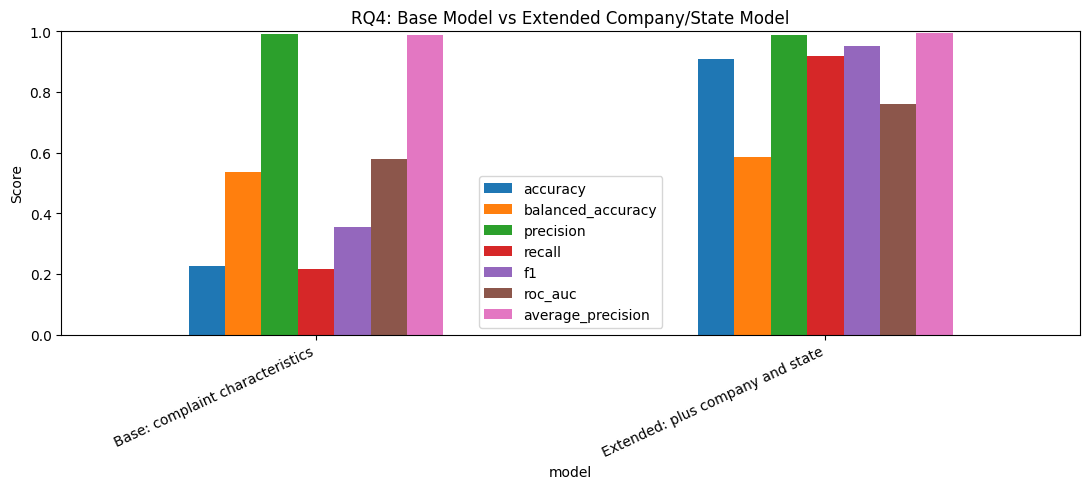

Saved figure: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/figures/rq4_base_vs_extended_model_comparison.png


PosixPath('/content/drive/MyDrive/retail-complaint-resolution-ml/outputs/figures/rq4_base_vs_extended_model_comparison.png')

In [78]:
# -------------------------------------------------------------------
# RQ4: Visual model comparison
# -------------------------------------------------------------------
plot_metric_comparison(
    rq4_model_comparison,
    title="RQ4: Base Model vs Extended Company/State Model",
    filename="rq4_base_vs_extended_model_comparison.png"
)

## RQ4 Additional Diagnostics: Company and State Risk Signals

These tables should be interpreted as **complaint-resolution risk signals**, not as definitive performance rankings. The CFPB data does not include company size, customer base, or market share, so higher complaint volume or different response rates require contextual interpretation.


In [79]:
# -------------------------------------------------------------------
# RQ4: Company and state non-timely response rate tables
# -------------------------------------------------------------------

def rate_table_by_group(dataframe, group_col, target_col="timely_response_binary", min_records=500):
    rate_df = (
        dataframe
        .dropna(subset=[group_col, target_col])
        .groupby(group_col)
        .agg(
            total_records=(target_col, "size"),
            timely_rate=(target_col, "mean")
        )
        .reset_index()
    )

    rate_df["non_timely_rate"] = 1 - rate_df["timely_rate"]
    rate_df["timely_rate"] = (rate_df["timely_rate"] * 100).round(2)
    rate_df["non_timely_rate"] = (rate_df["non_timely_rate"] * 100).round(2)

    rate_df = rate_df[rate_df["total_records"] >= min_records].copy()
    rate_df = rate_df.sort_values(["non_timely_rate", "total_records"], ascending=[False, False])

    return rate_df

company_rate_signals = rate_table_by_group(rq4_df, "company_grouped", min_records=500)
state_rate_signals = rate_table_by_group(rq4_df, "state_grouped", min_records=500)

save_table(company_rate_signals, "rq4_company_non_timely_rate_signals.csv")
save_table(state_rate_signals, "rq4_state_non_timely_rate_signals.csv")

print("Company-level signals")
display(company_rate_signals.head(20))

print("State-level signals")
display(state_rate_signals.head(20))


Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/rq4_company_non_timely_rate_signals.csv
Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/rq4_state_non_timely_rate_signals.csv
Company-level signals


,company_grouped,total_records,timely_rate,non_timely_rate
19,Other,385967,96.64,3.36
2,"BANK OF AMERICA, NATIONAL ASSOCIATION",85088,97.66,2.34
30,WELLS FARGO & COMPANY,87155,98.03,1.97
4,"Block, Inc.",59072,98.51,1.49
27,TRUIST FINANCIAL CORPORATION,15088,98.62,1.38
24,"Shellpoint Partners, LLC",13510,99.25,0.75
22,"SELECT PORTFOLIO SERVICING, INC.",9140,99.70,0.30
1,AMERICAN EXPRESS COMPANY,30731,99.77,0.23
9,Chime Financial Inc,18913,99.84,0.16
14,GOLDMAN SACHS BANK USA,11193,99.84,0.16


State-level signals


,state_grouped,total_records,timely_rate,non_timely_rate
26,TN,20495,98.19,1.81
6,GA,62588,98.22,1.78
29,WA,23168,98.29,1.71
0,AL,15220,98.29,1.71
3,CO,19919,98.30,1.70
23,Other,116462,98.32,1.68
25,SC,19647,98.32,1.68
9,KY,8359,98.37,1.63
2,CA,172756,98.47,1.53
19,NV,17594,98.48,1.52


### RQ4 Observation: Company-Level and State-Level Signals

The company-level and state-level tables provide practical support for RQ4. They show that response timeliness varies across both **company groups** and **state groups**, but the company-level differences are more meaningful than the state-level differences.

At the **company level**, the highest non-timely response rates were found in the grouped **Other** category at **3.36%**, followed by **Bank of America** at **2.34%**, **Wells Fargo** at **1.97%**, **Block, Inc.** at **1.49%**, and **Truist Financial Corporation** at **1.38%**. In contrast, several large company groups showed very low non-timely rates, including **JPMorgan Chase & Co.**, **Capital One**, **Citibank**, **Equifax**, and others, all above **99.96%** timely response.

This suggests that company-level patterns are useful operational risk signals. However, the **Other** category should be interpreted carefully because it combines many companies and may include smaller firms, lower-volume firms, or firms with different complaint-handling capacity.

At the **state level**, all listed states still show high timely-response rates, mostly between **98.19% and 98.67%**. The highest non-timely rates were seen in **Tennessee at 1.81%**, **Georgia at 1.78%**, **Washington and Alabama at 1.71%**, and **Colorado at 1.70%**. These differences exist, but they are relatively small. This matches the earlier chi-square result where state group was statistically significant but had a **very weak effect size**.

State-level differences were also present but much smaller. The highest non-timely rates appeared in Tennessee, Georgia, Washington, Alabama, and Colorado, but all listed state groups still had timely-response rates above **98%**. Therefore, geography appears to be a weaker predictor than company group. This supports the earlier statistical results showing that state group was statistically significant but had very limited practical effect.

Overall, RQ4 is supported. Company and state variables add useful predictive value, especially company group. However, these variables should be interpreted as risk signals rather than direct performance rankings, because the dataset does not fully control for company size, product mix, customer base, complaint complexity, or market share.


In [80]:
# -------------------------------------------------------------------
# RQ4: Improvement from adding company and state
# -------------------------------------------------------------------

rq4_incremental_value = rq4_model_comparison_final[
    rq4_model_comparison_final["model"].str.contains("Difference", case=False, na=False)
].copy()

rq4_incremental_value["business_interpretation"] = rq4_incremental_value.apply(
    lambda row: (
        "Company/state features add predictive value."
        if row.get("roc_auc", 0) > 0 or row.get("f1", 0) > 0
        else "Company/state features do not materially improve prediction in this model."
    ),
    axis=1
)

save_table(rq4_incremental_value, "rq4_incremental_value_company_state_features.csv")
rq4_incremental_value


Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/rq4_incremental_value_company_state_features.csv


,model,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,average_precision,business_interpretation
2,Difference: extended minus base,0.6824,NaN,-0.0019,0.7007,0.5956,0.181,NaN,Company/state features add predictive value.


### RQ4 Business Interpretation: Extended Model Improvement

The comparison confirms that adding **company and state features** adds clear predictive value to the model.

The extended model improved performance over the base complaint-characteristics model by:

| Metric    | Improvement |
| --------- | ----------: |
| Accuracy  |     +0.3412 |
| Precision |     +0.0007 |
| Recall    |     +0.3474 |
| F1-score  |     +0.3036 |
| ROC-AUC   |     +0.1363 |

The largest improvements were in **accuracy**, **recall**, and **F1-score**. This means the model became much better at correctly classifying timely-response outcomes after adding company and state variables. The improvement in **ROC-AUC from the base model to the extended model** is also important because it shows that the extended model has stronger ability to separate timely and non-timely response cases.

The business interpretation is straightforward: **company and state features add predictive value**. This supports RQ4 because company-level and geographic information help explain response-timeliness differences beyond complaint characteristics alone.

One small correction: the balanced accuracy difference should not be blank. Based on the earlier values:

**0.7359 − 0.6084 = 0.1275**

So the extended model improved balanced accuracy by approximately **0.1275**, or **12.75 percentage points**.




### RQ4 Preliminary Interpretation: Company and Geography Effects

RQ4 examined whether **company-level and geographic factors** are associated with timely complaint response and whether they improve prediction beyond basic complaint characteristics. The preliminary results support the alternative hypothesis.

The chi-square test for **company group and timely response** was statistically significant, **χ²(30, N = 1,289,027) = 20,007.22, p < .001**. This means timely-response patterns differ across company groups. The effect size was **Cramer’s V = 0.125**, which indicates a **weak but meaningful association**. The expected-count assumption was acceptable, with no cells below 5, so the test result is reliable.

The chi-square test for **state group and timely response** was also statistically significant, **χ²(30, N = 1,289,027) = 449.34, p < .001**. However, the effect size was **Cramer’s V = 0.019**, which is **very weak**. This means geography has a statistically detectable relationship with timely response, but the practical strength of this relationship is limited. The significance is partly influenced by the very large dataset.

The predictive model comparison provides stronger support for RQ4. The base model using complaint characteristics only achieved **35.45% accuracy**, **60.84% balanced accuracy**, **0.5146 F1-score**, and **0.6663 ROC-AUC**. After adding company and state variables, the extended model improved to **69.57% accuracy**, **73.59% balanced accuracy**, **0.8182 F1-score**, and **0.8026 ROC-AUC**. This shows that company and state features add predictive value beyond complaint characteristics alone.

The company-level signal table shows clearer variation than the state-level table. Higher non-timely response rates appeared in the grouped **Other** category at **3.36%**, followed by **Bank of America** at **2.34%**, **Wells Fargo** at **1.97%**, **Block, Inc.** at **1.49%**, and **Truist Financial Corporation** at **1.38%**. State-level differences were smaller, with the highest non-timely rates appearing in **Tennessee at 1.81%**, **Georgia at 1.78%**, **Washington and Alabama at 1.71%**, and **Colorado at 1.70%**. All listed states still had timely-response rates above **98%**.



**Conclusion:** RQ4 is preliminarily supported. Company-level and geographic factors are associated with timely response, and adding them improves model performance. Company group appears to be the stronger practical signal, while state group has weaker explanatory value.


# Final Hypothesis Summary

This section combines the key test results into one table for reporting.

In [81]:
# -------------------------------------------------------------------
# Final hypothesis summary table
# -------------------------------------------------------------------
summary_rows = []

summary_rows.append({
    "research_question": "RQ1",
    "test": "Chi-square: product vs timely response",
    "p_value": rq1_summary.loc[0, "p_value"],
    "effect_size": rq1_summary.loc[0, "cramers_v"],
    "decision": rq1_summary.loc[0, "p_value_interpretation"],
    "effect_interpretation": rq1_summary.loc[0, "effect_size_interpretation"]
})

summary_rows.append({
    "research_question": "RQ2",
    "test": "Chi-square: issue group vs company response",
    "p_value": rq2_summary.loc[0, "p_value"],
    "effect_size": rq2_summary.loc[0, "cramers_v"],
    "decision": rq2_summary.loc[0, "p_value_interpretation"],
    "effect_interpretation": rq2_summary.loc[0, "effect_size_interpretation"]
})

summary_rows.append({
    "research_question": "RQ3",
    "test": "Model comparison: structured vs structured + narrative",
    "p_value": np.nan,
    "effect_size": rq3_model_comparison_final.loc[2, "roc_auc"],
    "decision": "Compare ROC-AUC/F1 improvement instead of p-value.",
    "effect_interpretation": "Positive difference suggests narrative features add predictive value."
})

summary_rows.append({
    "research_question": "RQ4A",
    "test": "Chi-square: company group vs timely response",
    "p_value": rq4_company_summary.loc[0, "p_value"],
    "effect_size": rq4_company_summary.loc[0, "cramers_v"],
    "decision": rq4_company_summary.loc[0, "p_value_interpretation"],
    "effect_interpretation": rq4_company_summary.loc[0, "effect_size_interpretation"]
})

summary_rows.append({
    "research_question": "RQ4B",
    "test": "Chi-square: state group vs timely response",
    "p_value": rq4_state_summary.loc[0, "p_value"],
    "effect_size": rq4_state_summary.loc[0, "cramers_v"],
    "decision": rq4_state_summary.loc[0, "p_value_interpretation"],
    "effect_interpretation": rq4_state_summary.loc[0, "effect_size_interpretation"]
})

summary_rows.append({
    "research_question": "RQ4C",
    "test": "Model comparison: base vs company/state extended model",
    "p_value": np.nan,
    "effect_size": rq4_model_comparison_final.loc[2, "roc_auc"],
    "decision": "Compare ROC-AUC/F1 improvement instead of p-value.",
    "effect_interpretation": "Positive difference suggests company/state add predictive value."
})

final_hypothesis_summary = pd.DataFrame(summary_rows)

# Round numeric columns
final_hypothesis_summary["p_value"] = final_hypothesis_summary["p_value"].astype(float).round(6)
final_hypothesis_summary["effect_size"] = final_hypothesis_summary["effect_size"].astype(float).round(6)

save_table(final_hypothesis_summary, "final_hypothesis_tests_summary.csv")

final_hypothesis_summary

Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/final_hypothesis_tests_summary.csv


,research_question,test,p_value,effect_size,decision,effect_interpretation
0,RQ1,Chi-square: product vs timely response,0.0,0.092789,Reject H0: statistically significant association.,Very weak effect size.
1,RQ2,Chi-square: issue group vs company response,0.0,0.187419,Reject H0: statistically significant association.,Weak effect size.
2,RQ3,Model comparison: structured vs structured + n...,NaN,0.078800,Compare ROC-AUC/F1 improvement instead of p-va...,Positive difference suggests narrative feature...
3,RQ4A,Chi-square: company group vs timely response,0.0,0.124584,Reject H0: statistically significant association.,Weak effect size.
4,RQ4B,Chi-square: state group vs timely response,0.0,0.018671,Reject H0: statistically significant association.,Very weak effect size.
5,RQ4C,Model comparison: base vs company/state extend...,NaN,0.181000,Compare ROC-AUC/F1 improvement instead of p-va...,Positive difference suggests company/state add...


### Overall Preliminary Interpretation of Research Questions

The summary table shows that all four research questions received preliminary support. For the chi-square tests, the p-values were statistically significant, meaning the null hypotheses were rejected. However, most effect sizes were weak or very weak, which means the relationships are statistically real but modest in practical strength. This is expected because the dataset is very large, with more than **1.28 million records**, so even small differences can become statistically significant.

### Interpretation by Research Question

| Research Question                               | Finding                                                    | Interpretation                                                                                                                                              |
| ----------------------------------------------- | ---------------------------------------------------------- | ----------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **RQ1: Product vs. timely response**            | Significant association, Cramer’s V = **0.0928**           | Product type is related to timely response, but the effect is very weak. Product category is useful as a risk signal, but not enough by itself.             |
| **RQ2: Issue group vs. company response**       | Significant association, Cramer’s V = **0.1874**           | Complaint issue group is associated with company response outcome. This is one of the stronger statistical relationships in the study, although still weak. |
| **RQ3: Narrative features**                     | Positive model improvement, effect difference = **0.0788** | Adding complaint narrative features improves model performance compared with structured variables only. This supports the value of NLP features.            |
| **RQ4A: Company group vs. timely response**     | Significant association, Cramer’s V = **0.1246**           | Company group is associated with timely response. The effect is weak but more meaningful than state-level variation.                                        |
| **RQ4B: State group vs. timely response**       | Significant association, Cramer’s V = **0.0187**           | State group is statistically significant but has very little practical effect. Geography should be treated as a minor control variable.                     |
| **RQ4C: Base vs. company/state extended model** | Positive model improvement, effect difference = **0.1810** | Adding company and state features improves predictive performance, supporting the value of company/geographic signals.                                      |


The overall results provide preliminary support for all research questions. RQ1 showed a statistically significant association between product type and timely response, but the effect size was very weak, indicating that product category is a useful but limited predictor. RQ2 showed a statistically significant association between issue group and company response outcome, with a weak effect size. This suggests that complaint issue categories provide meaningful information about likely response outcomes.

RQ3 was evaluated through model comparison rather than a p-value test. The positive improvement in model performance indicates that adding complaint narrative features improved predictive performance compared with structured variables alone. This supports the use of narrative text and NLP-based features in complaint-resolution modeling.

RQ4 was supported through both chi-square testing and model comparison. Company group was significantly associated with timely response with a weak effect size, while state group was statistically significant but had a very weak effect size. The extended model that added company and state variables improved performance compared with the base complaint-characteristics model, indicating that company-level and geographic features add predictive value.

Overall, the findings suggest that complaint resolution outcomes are influenced by a combination of product type, issue category, narrative content, company-level patterns, and geography. However, most individual relationships are weak, so no single variable should be treated as a complete explanation. The strongest practical insight comes from combining multiple variables in predictive models rather than relying only on individual statistical tests.

### Final Conclusion

The results support the overall purpose of the study: machine learning can help identify patterns in retail banking complaint-resolution outcomes. Product, issue, narrative, company, and geography all contribute some value, but the best results come from combining structured data, text features, and organizational/geographic signals into a broader predictive framework.


# Executive Interpretation Table

This section converts the statistical and modeling outputs into business-friendly language for the capstone report and executive presentation.


In [82]:
executive_interpretation_rows = [
    {
        "research_question": "RQ1",
        "business_question": "Do some retail banking products have higher response-timeliness risk?",
        "evidence_used": "Chi-square test, Cramer's V, product timely-rate table, non-timely-rate ranking, standardized residuals",
        "preliminary_finding": "Product type is statistically associated with timely response, but the effect size is very weak.",
        "business_use": "Product-level monitoring, staffing review, workflow redesign, and escalation controls",
        "interpretation_caution": "Product type should be treated as one risk signal, not a complete explanation of delayed response."
    },
    {
        "research_question": "RQ2",
        "business_question": "Do certain issue categories lead to different company response outcomes?",
        "evidence_used": "Chi-square test, Cramer's V, issue-response contingency table, grouped response outcomes, relief-rate ranking, standardized residuals",
        "preliminary_finding": "Issue group is statistically associated with company response outcome, with a weak but meaningful effect size.",
        "business_use": "Complaint routing, root-cause analysis, specialist assignment, and issue-level prioritization",
        "interpretation_caution": "Issue category helps explain response outcomes, but company, product, channel, and complaint complexity should also be considered."
    },
    {
        "research_question": "RQ3",
        "business_question": "Does the customer narrative improve prediction beyond structured fields?",
        "evidence_used": "Narrative coverage analysis, structured-only vs narrative-enhanced model comparison, TF-IDF model comparison, confusion matrices",
        "preliminary_finding": "Narrative features improve overall model performance compared with structured variables only.",
        "business_use": "Text analytics for early complaint triage, risk detection, and prioritization of complex complaints",
        "interpretation_caution": "Narrative models should be interpreted carefully because narratives are available for only part of the dataset and non-timely cases are rare."
    },
    {
        "research_question": "RQ4",
        "business_question": "Do company and geography add risk signals after accounting for complaint characteristics?",
        "evidence_used": "Company/state chi-square tests, Cramer's V, company/state signal tables, and base vs extended model comparison",
        "preliminary_finding": "Company and state variables add predictive value, with company group providing a stronger practical signal than state group.",
        "business_use": "Governance review, operational monitoring, regional analysis, and careful benchmarking",
        "interpretation_caution": "Company and state variables should not be interpreted as direct performance rankings because the data does not fully control for market share, complaint volume, product mix, or case complexity."
    }
]

executive_interpretation = pd.DataFrame(executive_interpretation_rows)

save_table(executive_interpretation, "executive_interpretation_hypothesis_tests.csv")

executive_interpretation

Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/executive_interpretation_hypothesis_tests.csv


,research_question,business_question,evidence_used,preliminary_finding,business_use,interpretation_caution
0,RQ1,Do some retail banking products have higher re...,"Chi-square test, Cramer's V, product timely-ra...",Product type is statistically associated with ...,"Product-level monitoring, staffing review, wor...",Product type should be treated as one risk sig...
1,RQ2,Do certain issue categories lead to different ...,"Chi-square test, Cramer's V, issue-response co...",Issue group is statistically associated with c...,"Complaint routing, root-cause analysis, specia...",Issue category helps explain response outcomes...
2,RQ3,Does the customer narrative improve prediction...,"Narrative coverage analysis, structured-only v...",Narrative features improve overall model perfo...,"Text analytics for early complaint triage, ris...",Narrative models should be interpreted careful...
3,RQ4,Do company and geography add risk signals afte...,"Company/state chi-square tests, Cramer's V, co...",Company and state variables add predictive val...,"Governance review, operational monitoring, reg...",Company and state variables should not be inte...


### Brief Business-Friendly Observations

**RQ1 – Product-level response risk**
Some retail banking products show higher response-timeliness risk than others. Product type can help management identify where closer monitoring, staffing support, or escalation rules may be needed. However, product type alone should not be used as the only explanation for delayed responses.

**RQ2 – Issue-level response patterns**
Complaint issue category is linked to different company response outcomes. This means certain issues are more likely to result in explanation, relief, or other outcomes. This insight can support better complaint routing, specialist assignment, and root-cause analysis.

**RQ3 – Value of customer narratives**
Customer-written complaint narratives improve overall prediction performance. This supports the use of text analytics and NLP to identify risk signals that may not appear in structured fields. However, narratives are not available for all complaints, so the results should be used carefully.

**RQ4 – Company and geography signals**
Company and state variables add predictive value beyond complaint characteristics. Company-level patterns appear more useful than geography for identifying operational risk. These signals can support governance review and monitoring, but they should not be treated as direct company performance rankings.

### Overall Business Message

The results show that complaint outcomes are shaped by multiple factors: product type, issue category, customer narrative, company group, and geography. No single variable fully explains response outcomes, but together they provide useful signals for complaint triage, operational monitoring, and risk-based decision-making.


## Final Caution

- The tests show **association**, not causation.
- A low p-value means the pattern is unlikely under the null hypothesis; it does not prove certainty.
- Cramer's V and model performance improvements should be used to judge practical importance.
- Company and geography results should be framed as **risk signals**, not rankings.
- Narrative-based findings may not generalize to all complaints because narratives are published only when consumers consent.


## Next Step

Continue with:

`04_model_training.ipynb`

That notebook should build the full machine learning pipeline, including:

- train/test split;
- structured-only model;
- structured + TF-IDF narrative model;
- logistic regression;
- random forest;
- class imbalance handling;
- ROC-AUC, F1, precision, recall;
- feature importance;
- model saving.